# Main Serial time

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
# df_time = pd.read_csv('/content/BTP_FinalData - Sheet1.csv')
df_time = pd.read_csv('/content/drive/MyDrive/BTP_Sensor 2024/OneDrive_1_9-5-2024/BTP_Time_data.csv')
# print(df_time.head())
df_time

,Repeat,Point,Gate Voltage,Gate Current,Gate Time,Drain Voltage,Drain Current,Drain Time,Concentration (mM)
0,1,1,-0.4,-1.900000e-06,0.0,-0.5,-0.000679,0.0,20.0
1,1,2,-0.4,-1.900000e-06,0.5,-0.5,-0.000679,0.5,20.0
2,1,3,-0.4,-1.600000e-06,1.0,-0.5,-0.000679,1.0,20.0
3,1,4,-0.4,-1.400000e-06,1.5,-0.5,-0.000680,1.5,20.0
4,1,5,-0.4,-1.600000e-06,2.0,-0.5,-0.000680,2.0,20.0
...,...,...,...,...,...,...,...,...,...
796,1,801,-0.4,-1.800000e-06,89.0,-0.5,-0.000362,89.0,150.0
797,1,802,-0.4,-9.000000e-07,89.5,-0.5,-0.000362,89.5,150.0
798,1,803,-0.4,-1.600000e-06,90.0,-0.5,-0.000362,90.0,150.0
799,1,804,-0.4,-2.200000e-06,90.5,-0.5,-0.000361,90.5,150.0


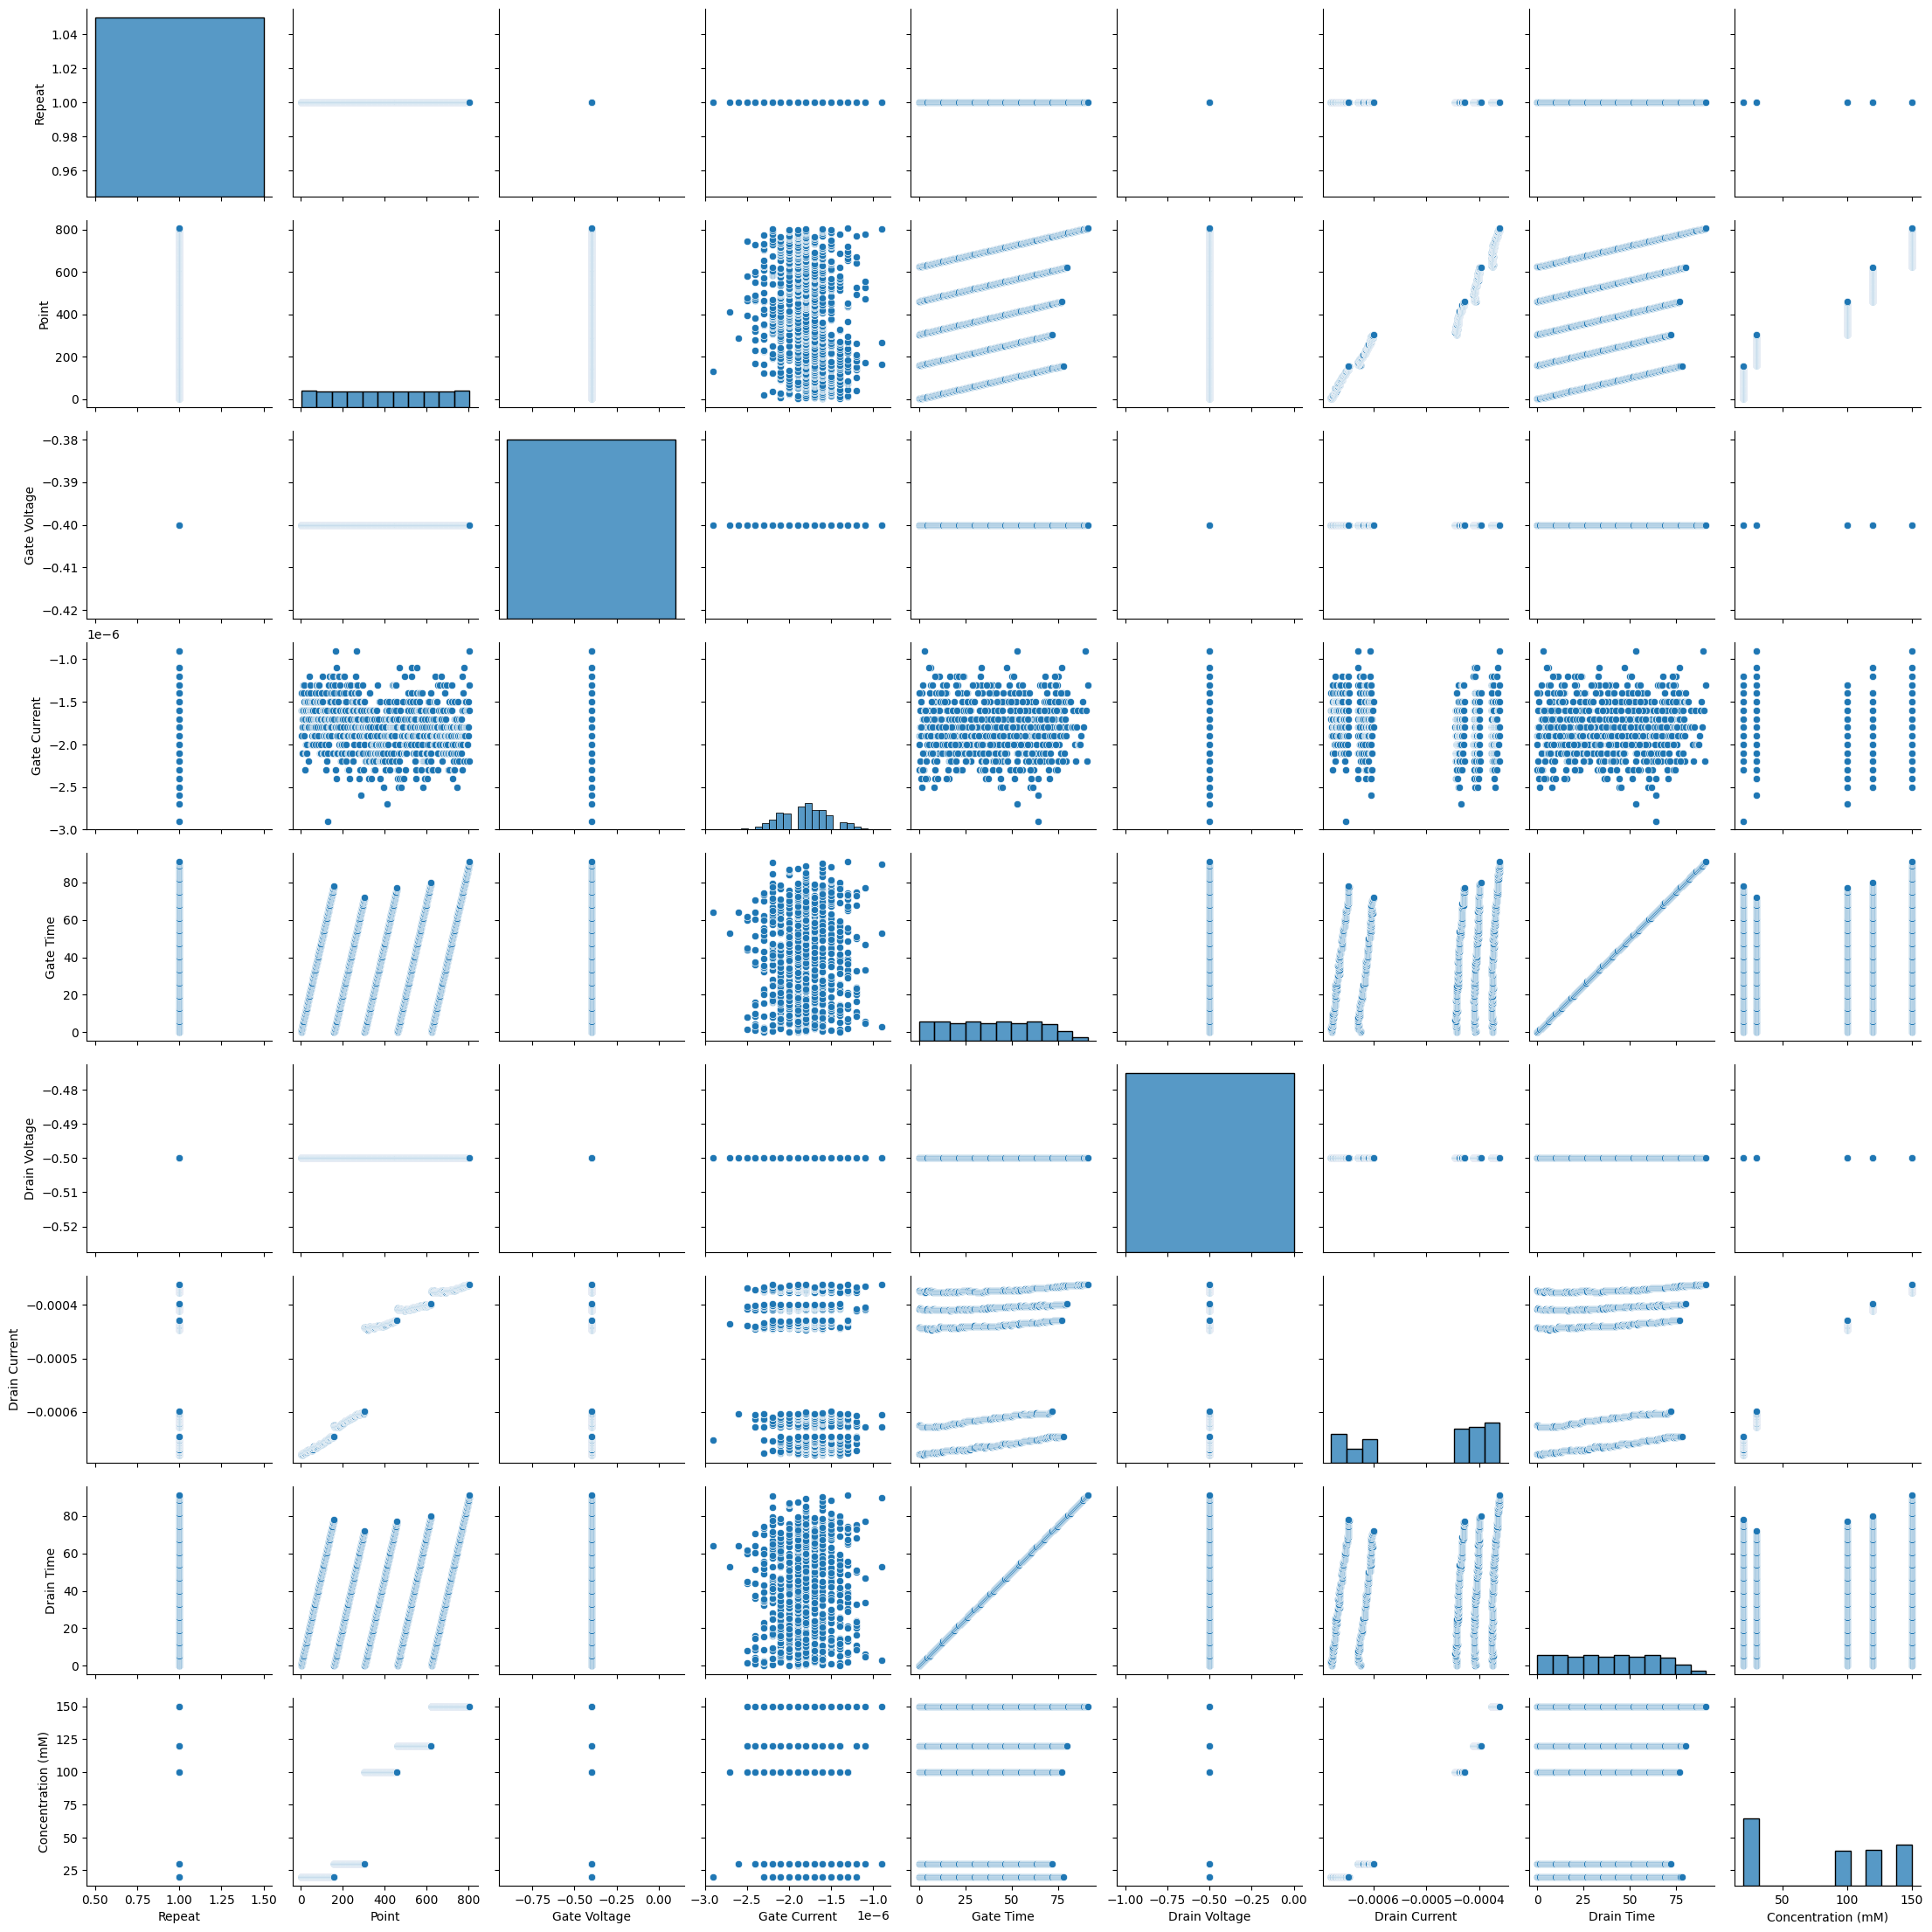

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.pairplot(df_time)
plt.show()

In [ ]:
data = df_time
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 801 entries, 0 to 800
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Repeat              801 non-null    int64  
 1   Point               801 non-null    int64  
 2   Gate Voltage        801 non-null    float64
 3   Gate Current        801 non-null    float64
 4   Gate Time           801 non-null    float64
 5   Drain Voltage       801 non-null    float64
 6   Drain Current       801 non-null    float64
 7   Drain Time          801 non-null    float64
 8   Concentration (mM)  801 non-null    float64
dtypes: float64(7), int64(2)
memory usage: 56.4 KB


In [ ]:
data.describe()

,Repeat,Point,Gate Voltage,Gate Current,Gate Time,Drain Voltage,Drain Current,Drain Time,Concentration (mM)
count,801.0,801.000000,8.010000e+02,8.010000e+02,801.000000,801.0,801.000000,801.000000,801.000000
mean,1.0,403.084894,-4.000000e-01,-1.809114e-06,40.046192,-0.5,-0.000492,40.046192,87.091136
std,0.0,232.783613,1.388646e-15,2.934780e-07,23.576466,0.0,0.000118,23.576466,51.280142
min,1.0,1.000000,-4.000000e-01,-2.900000e-06,0.000000,-0.5,-0.000680,0.000000,20.000000
25%,1.0,202.000000,-4.000000e-01,-2.000000e-06,20.000000,-0.5,-0.000621,20.000000,30.000000
50%,1.0,403.000000,-4.000000e-01,-1.800000e-06,40.000000,-0.5,-0.000437,40.000000,100.000000
75%,1.0,604.000000,-4.000000e-01,-1.600000e-06,60.000000,-0.5,-0.000400,60.000000,120.000000
max,1.0,805.000000,-4.000000e-01,-9.000000e-07,91.000000,-0.5,-0.000361,91.000000,150.000000


In [ ]:
data.nunique()

,0
Repeat,1
Point,801
Gate Voltage,1
Gate Current,19
Gate Time,183
Drain Voltage,1
Drain Current,114
Drain Time,183
Concentration (mM),5


In [ ]:
data = data.drop(['Repeat', 'Drain Time','Gate Current','Drain Voltage','Point'], axis=1)
data

,Gate Voltage,Gate Time,Drain Current,Concentration (mM)
0,-0.4,0.0,-0.000679,20.0
1,-0.4,0.5,-0.000679,20.0
2,-0.4,1.0,-0.000679,20.0
3,-0.4,1.5,-0.000680,20.0
4,-0.4,2.0,-0.000680,20.0
...,...,...,...,...
796,-0.4,89.0,-0.000362,150.0
797,-0.4,89.5,-0.000362,150.0
798,-0.4,90.0,-0.000362,150.0
799,-0.4,90.5,-0.000361,150.0


In [ ]:
print(f"Number of duplicate rows: {data.duplicated().sum()}")

Number of duplicate rows: 0


In [ ]:
data.isnull().sum()

,0
Gate Voltage,0
Gate Time,0
Drain Current,0
Concentration (mM),0


In [ ]:
# data = data.dropna()
# data.isnull().sum()

In [ ]:
# data = data.sort_values(by=['Concentration (mM)','Drain Current']).reset_index(drop=True)
# Generate new time series values for "Gate Time"
import numpy as np
time_series = np.arange(0, len(data) * 0.5, 0.5)  # increment by 0.5 for each row
data['Gate Time'] = time_series
data

,Gate Voltage,Gate Time,Drain Current,Concentration (mM)
0,-0.4,0.0,-0.000679,20.0
1,-0.4,0.5,-0.000679,20.0
2,-0.4,1.0,-0.000679,20.0
3,-0.4,1.5,-0.000680,20.0
4,-0.4,2.0,-0.000680,20.0
...,...,...,...,...
796,-0.4,398.0,-0.000362,150.0
797,-0.4,398.5,-0.000362,150.0
798,-0.4,399.0,-0.000362,150.0
799,-0.4,399.5,-0.000361,150.0


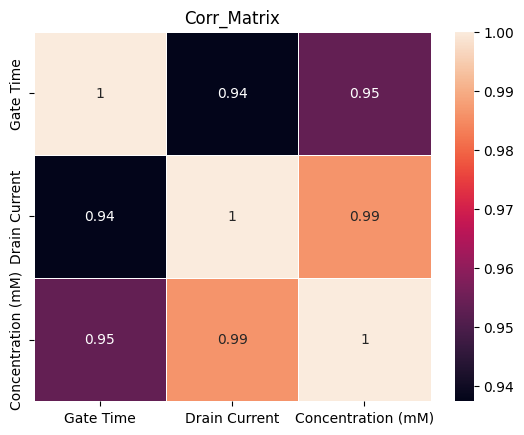

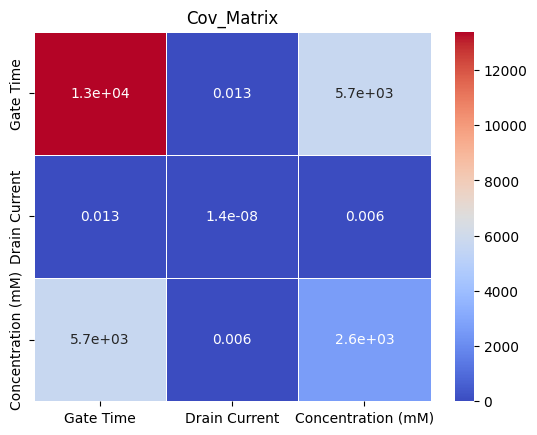

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
corr_mat=data.iloc[:, 1:].corr()
sns.heatmap(corr_mat,annot=True,linewidth=.5)
plt.title('Corr_Matrix')
plt.show()
cov_mat=data.iloc[:, 1:].cov()
sns.heatmap(cov_mat,annot=True,linewidth=.5,cmap='coolwarm')
plt.title('Cov_Matrix')
plt.show()

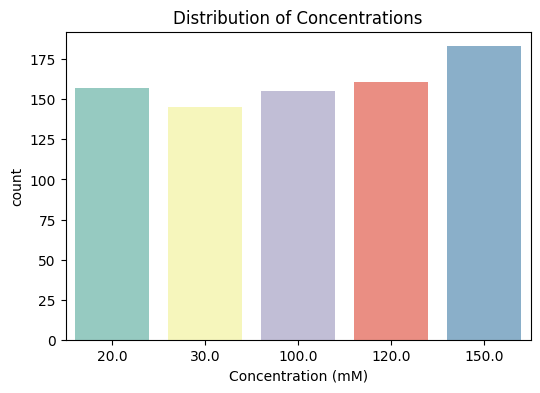

In [ ]:
# Visualize the distribution of the 'Conc' column
plt.figure(figsize=(6, 4))
sns.countplot(x='Concentration (mM)', data=data, palette='Set3')
plt.title('Distribution of Concentrations')
plt.show()

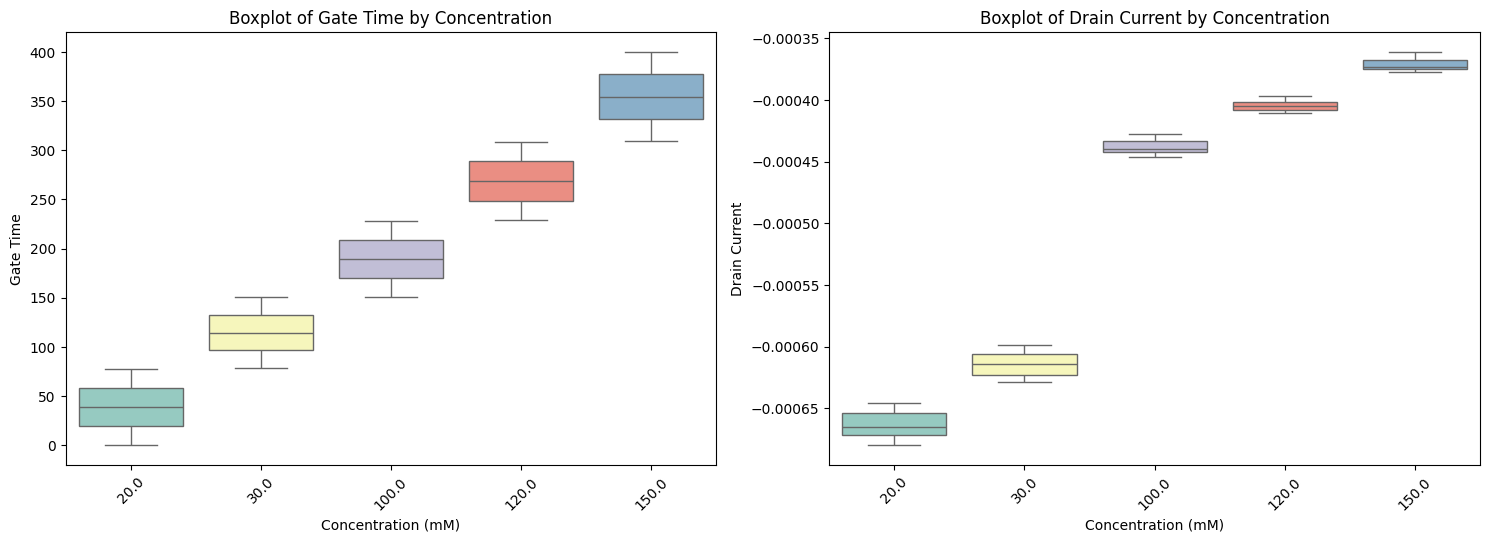

In [ ]:
plt.figure(figsize=(15, 10))  # Adjust figure size for multiple subplots

for i, col in enumerate(['Gate Time','Drain Current']):
    plt.subplot(2, 2, i + 1)  # Create subplots (adjust rows and columns as needed)
    sns.boxplot(x='Concentration (mM)', y=col, data=data, palette="Set3") # Use a color palette
    plt.title(f'Boxplot of {col} by Concentration')
    plt.xticks(rotation=45) # Rotate x-axis labels if needed
    plt.tight_layout() # Adjust layout to prevent overlapping

plt.show()

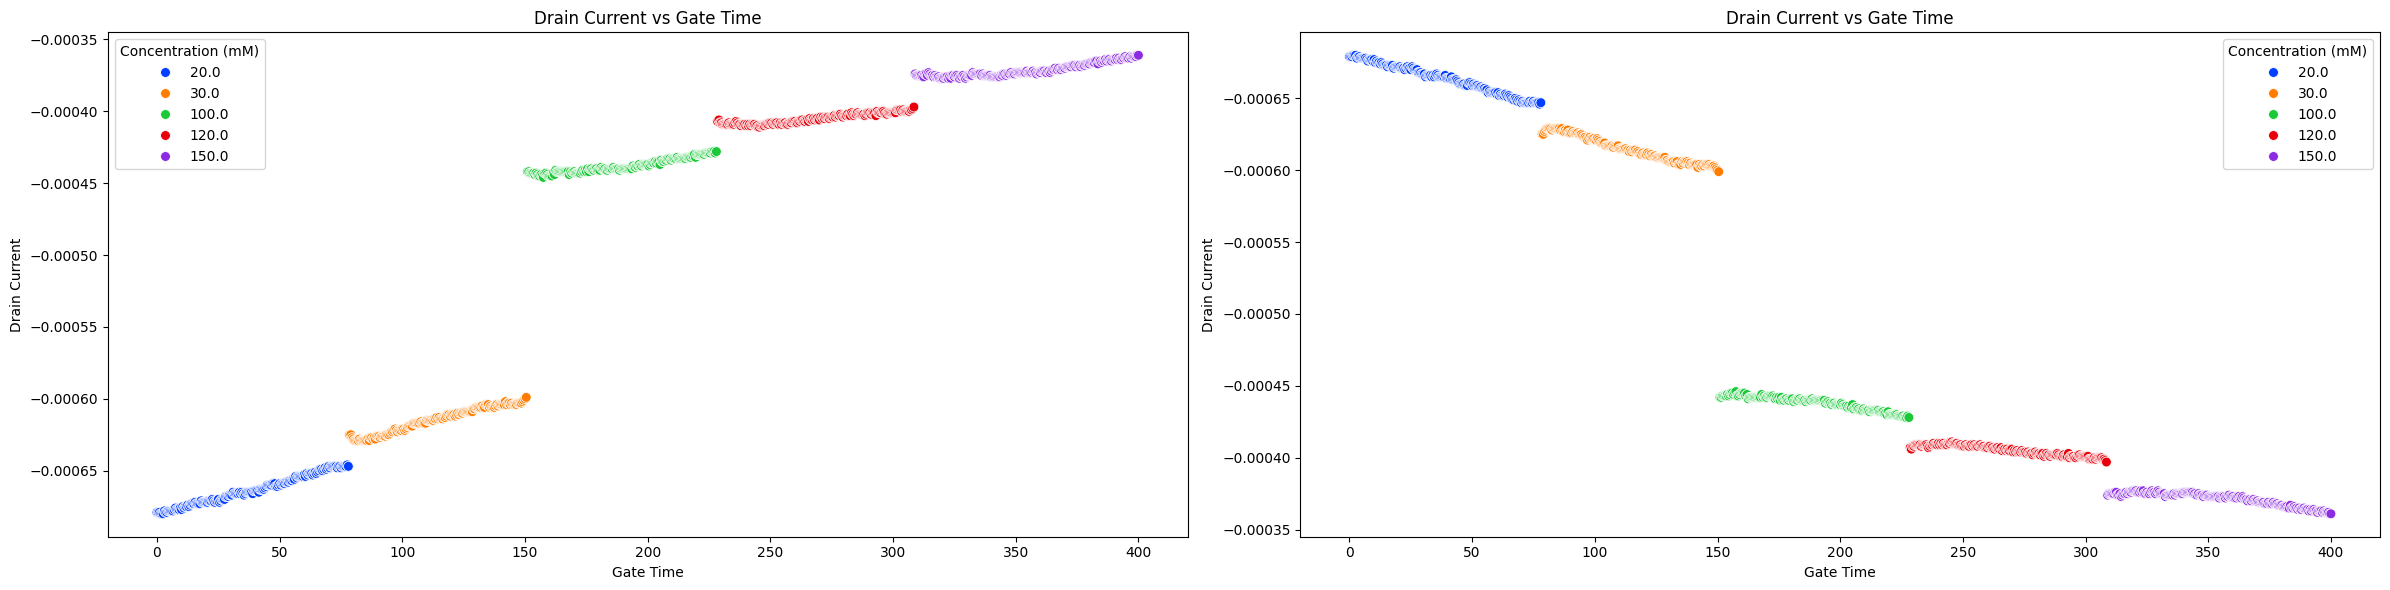

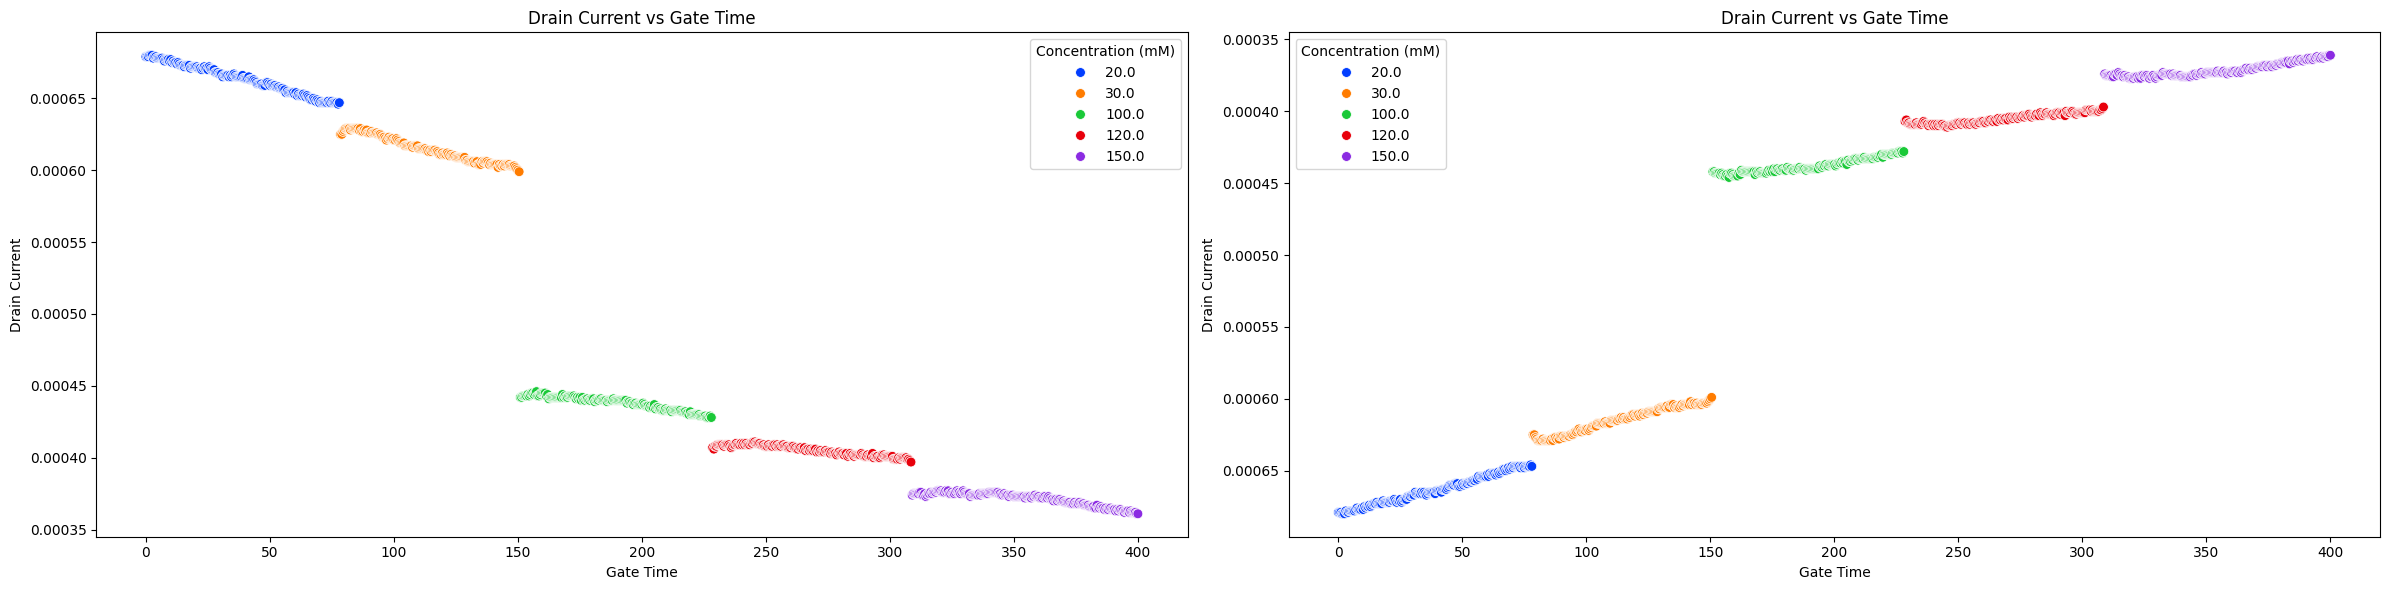

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 6))  # 1 row, 2 columns of subplots
# First subplot (original y-axis)
sns.scatterplot(x='Gate Time', y='Drain Current', hue='Concentration (mM)', data=data, palette='bright', s=50, ax=ax1)
ax1.set_title('Drain Current vs Gate Time')
ax1.set_xlabel('Gate Time')
ax1.set_ylabel('Drain Current')
# Second subplot (inverted y-axis)
sns.scatterplot(x='Gate Time', y='Drain Current', hue='Concentration (mM)', data=data, palette='bright', s=50, ax=ax2)
ax2.set_title('Drain Current vs Gate Time')
ax2.set_xlabel('Gate Time')
ax2.set_ylabel('Drain Current')
ax2.invert_yaxis()  # Invert the y-axis for the second subplot
plt.tight_layout()  # Adjust layout to avoid overlapping
plt.show()
#-----------------------------------------------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 6))  # 1 row, 2 columns of subplots
# First subplot (original y-axis)
sns.scatterplot(x='Gate Time', y=data['Drain Current'].abs(), hue='Concentration (mM)', data=data, palette='bright', s=50, ax=ax1)
ax1.set_title('Drain Current vs Gate Time')
ax1.set_xlabel('Gate Time')
ax1.set_ylabel('Drain Current')
# Second subplot (inverted y-axis)
sns.scatterplot(x='Gate Time', y=data['Drain Current'].abs(), hue='Concentration (mM)', data=data, palette='bright', s=50, ax=ax2)
ax2.set_title('Drain Current vs Gate Time')
ax2.set_xlabel('Gate Time')
ax2.set_ylabel('Drain Current')
ax2.invert_yaxis()  # Invert the y-axis for the second subplot
plt.tight_layout()  # Adjust layout to avoid overlapping
plt.show()

#With Gate Voltage, Serial Gate Time and  Drain Current

In [ ]:
X = data[['Gate Voltage','Gate Time','Drain Current']]  # Features
y = data['Concentration (mM)']  # Target variable

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# train_data = pd.DataFrame({'Drain Current': X_train['Drain Current'], 'Concentration (mM)': y_train})
# test_data = pd.DataFrame({'Drain Current': X_test['Drain Current'], 'Concentration (mM)': y_test})

# # Count entries for each concentration in the training set
# train_counts = train_data['Concentration (mM)'].value_counts()
# print("Training set concentration counts:")
# display(train_counts)

# # Count entries for each concentration in the testing set
# test_counts = test_data['Concentration (mM)'].value_counts()
# print("\nTesting set concentration counts:")
# test_counts

In [ ]:
# # pip install imbalanced-learn
# from imblearn.over_sampling import SMOTE

# smote = SMOTE(random_state=42)
# X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# train_data1 = pd.DataFrame({'Drain Current': X_train_resampled['Drain Current'], 'Concentration (mM)': y_train_resampled})
# test_data1 = pd.DataFrame({'Drain Current': X_test['Drain Current'], 'Concentration (mM)': y_test})

# # Count entries for each concentration in the training set
# train_counts = train_data1['Concentration (mM)'].value_counts()
# print("Training set concentration counts:")
# display(train_counts)

# # Count entries for each concentration in the testing set
# test_counts = test_data1['Concentration (mM)'].value_counts()
# print("\nTesting set concentration counts:")
# test_counts

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
# X_train_resampled_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

Linear Regression:
Mean Squared Error: 54.02002306470774
Root Mean Squared Error: 7.34983149906906
Mean Absolute Error: 6.0275274657834235
R-squared: 0.9795933244649274
---
Ridge Regression:
Mean Squared Error: 53.99204291148765
Root Mean Squared Error: 7.347927797106315
Mean Absolute Error: 6.018170047966504
R-squared: 0.9796038942847052
---
Lasso Regression:
Mean Squared Error: 54.62325018817031
Root Mean Squared Error: 7.390754372063133
Mean Absolute Error: 6.036961294567706
R-squared: 0.9793654485869828
---
Gaussian Process:
Mean Squared Error: 0.07759197034191434
Root Mean Squared Error: 0.2785533527744987
Mean Absolute Error: 0.1919424215458935
R-squared: 0.9999706887544088
---
Support Vector Machine:
Mean Squared Error: 22.064313980178024
Root Mean Squared Error: 4.697266649890979
Mean Absolute Error: 3.2908596037028626
R-squared: 0.9916649554969994
---
Gradient Boosting:
Mean Squared Error: 3.1803571123433523
Root Mean Squared Error: 1.783355576530758
Mean Absolute Error: 0.185

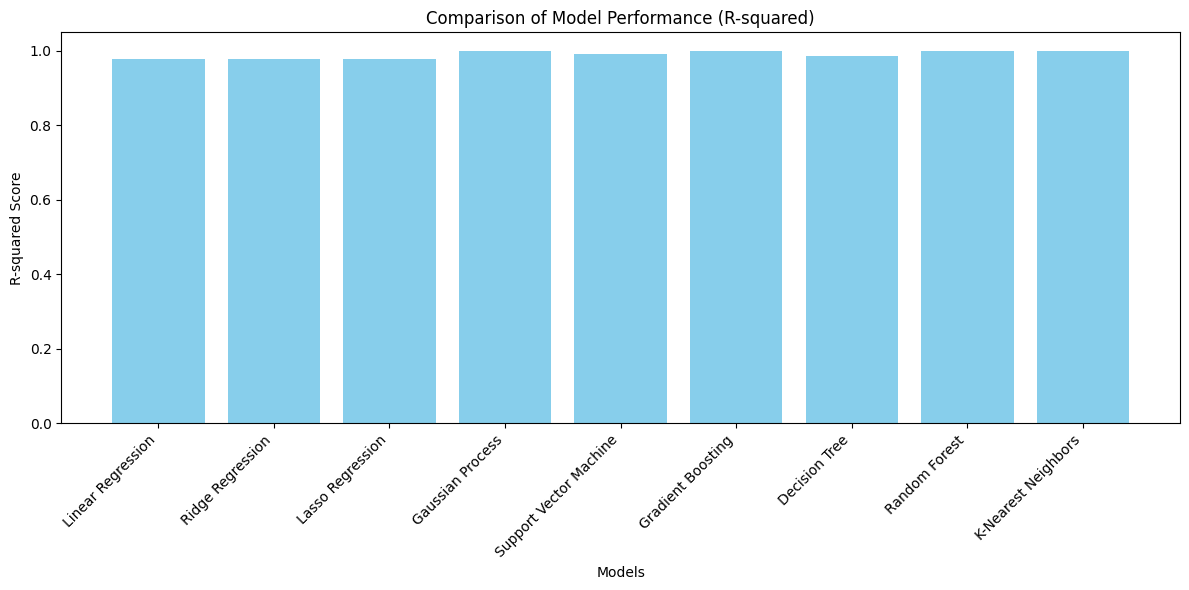

In [ ]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from imblearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Train different models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(),
    'Gaussian Process': GaussianProcessRegressor(),
    'Support Vector Machine': SVR(),
    'Gradient Boosting': GradientBoostingRegressor(),
    'Decision Tree': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor(),
    'K-Nearest Neighbors': KNeighborsRegressor()
}

model_names = []
r2_scores = []
predictions = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)  # Calculate RMSE from MSE
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    r2_scores.append(r2)
    model_names.append(name)
    predictions.append(y_pred)

    print(f'{name}:')
    print(f'Mean Squared Error: {mse}')
    print(f'Root Mean Squared Error: {rmse}') # Changed label to reflect RMSE
    print(f'Mean Absolute Error: {mae}')
    print(f'R-squared: {r2}')
    print('---')

# Create the comparison plot
plt.figure(figsize=(12, 6))
plt.bar(model_names, r2_scores, color='skyblue')
plt.xlabel("Models")
plt.ylabel("R-squared Score")
plt.title("Comparison of Model Performance (R-squared)")
plt.xticks(rotation=45, ha="right")  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

In [ ]:
# # Train different models
# resampled_models = {
#     'Linear Regression': LinearRegression(),
#     'Ridge Regression': Ridge(),
#     'Lasso Regression': Lasso(),
#     'Gaussian Process': GaussianProcessRegressor(),
#     'Support Vector Machine': SVR(),
#     'Gradient Boosting': GradientBoostingRegressor(),
#     'Decision Tree': DecisionTreeRegressor(),
#     'Random Forest': RandomForestRegressor(),
#     'K-Nearest Neighbors': KNeighborsRegressor()
# }

# model_names_resampled = []
# r2_scores_resampled = []
# predictions_resampled = []

# for name, resampled_model in resampled_models.items():
#     resampled_model.fit(X_train_resampled_scaled, y_train_resampled)
#     y_pred = resampled_model.predict(X_test_scaled)

#     mse = mean_squared_error(y_test, y_pred)
#     rmse = np.sqrt(mse)  # Calculate RMSE from MSE
#     mae = mean_absolute_error(y_test, y_pred)
#     r2 = r2_score(y_test, y_pred)
#     r2_scores_resampled.append(r2)
#     model_names_resampled.append(name)
#     predictions_resampled.append(y_pred)

#     print(f'{name}:')
#     print(f'Mean Squared Error: {mse}')
#     print(f'Root Mean Squared Error: {rmse}') # Changed label to reflect RMSE
#     print(f'Mean Absolute Error: {mae}')
#     print(f'R-squared: {r2}')
#     print('---')

# # Create the comparison plot
# plt.figure(figsize=(12, 6))
# plt.bar(model_names_resampled, r2_scores_resampled, color='skyblue')
# plt.xlabel("Models")
# plt.ylabel("R-squared Score")
# plt.title("Comparison of Model Performance (R-squared)")
# plt.xticks(rotation=45, ha="right")  # Rotate x-axis labels for better readability
# plt.tight_layout()
# plt.show()

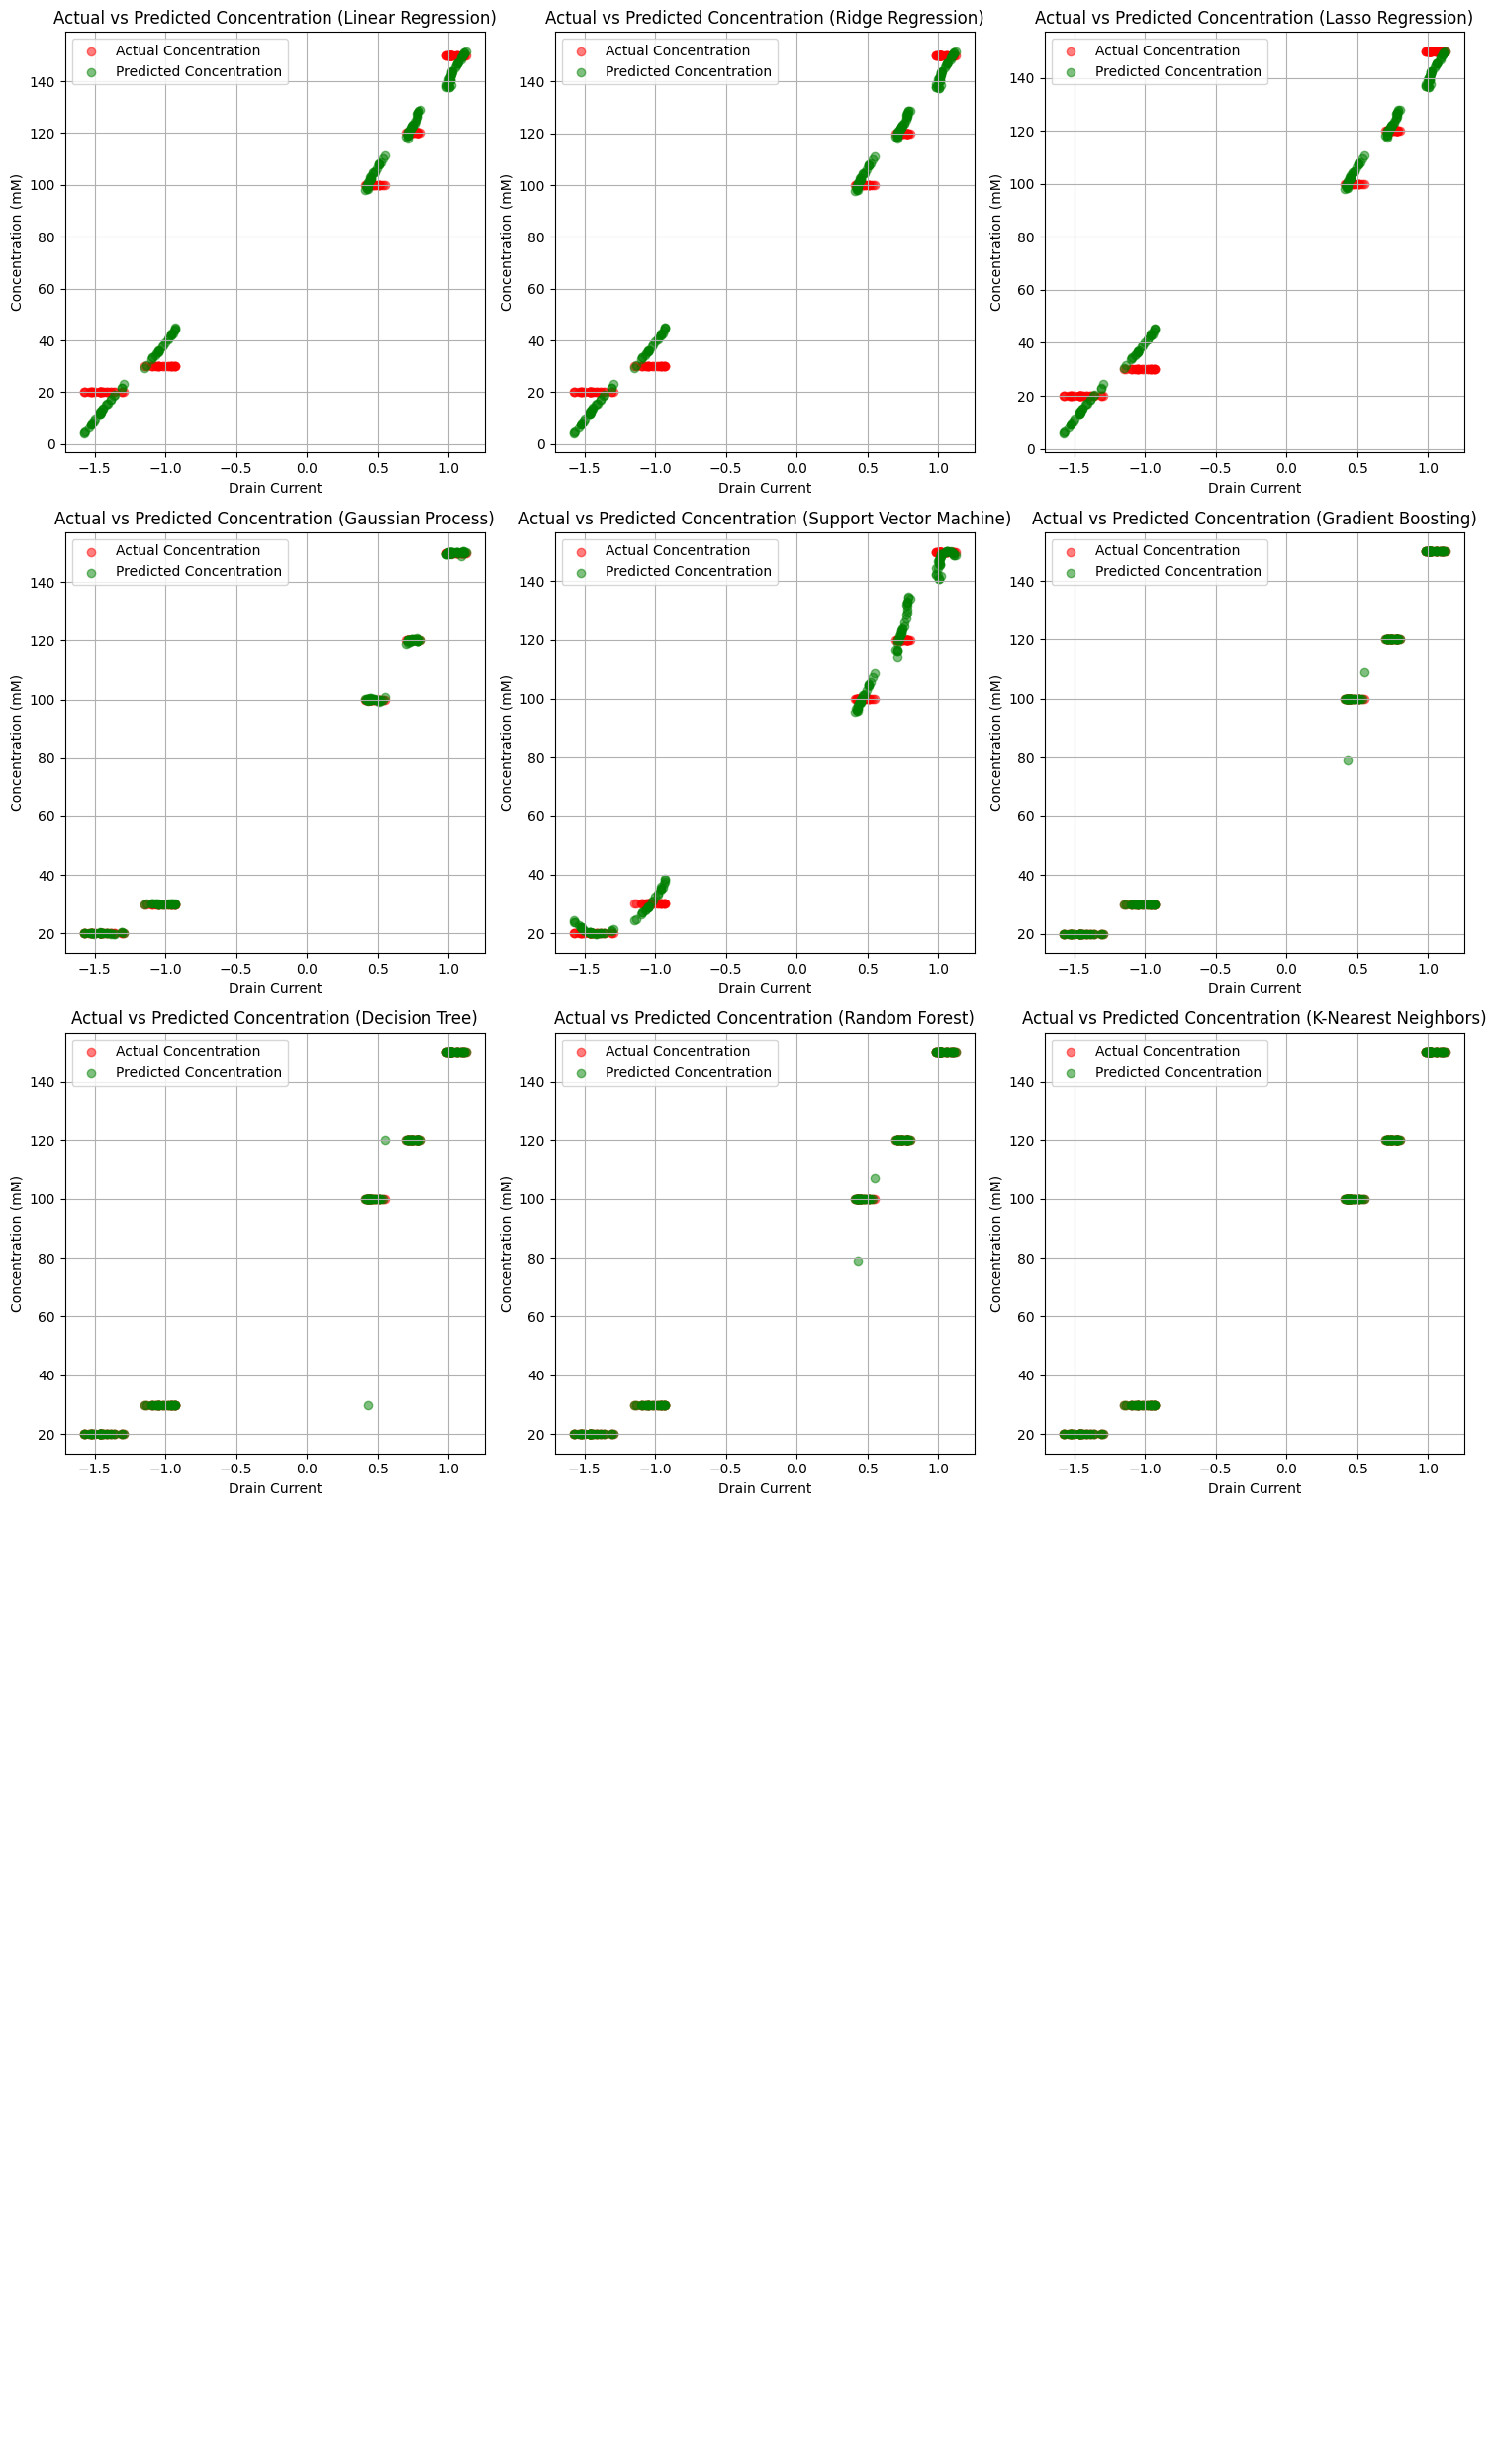

In [ ]:
num_models = len(models)
fig, axes = plt.subplots(nrows=(num_models + 1) // 2, ncols=3, figsize=(15, 5 * ((num_models + 1) // 2)))
axes = axes.flatten()  # Flatten the axes array for easier iteration

for i, (name, model) in enumerate(models.items()):
    y_pred = predictions[i]
    axes[i].scatter(X_test_scaled[:,2], y_test, color='red', label='Actual Concentration', alpha=0.5)
    axes[i].scatter(X_test_scaled[:,2], y_pred, color='green', label='Predicted Concentration', alpha=0.5)
    axes[i].set_xlabel('Drain Current')
    axes[i].set_ylabel('Concentration (mM)')
    axes[i].set_title(f'Actual vs Predicted Concentration ({name})')
    axes[i].legend()
    axes[i].grid()

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

#with Serial Gate Time and Drain Current

Linear Regression:
Mean Squared Error: 54.020023064707736
Root Mean Squared Error: 7.349831499069059
Mean Absolute Error: 6.027527465783423
R-squared: 0.9795933244649274
---
Ridge Regression:
Mean Squared Error: 53.99204291148764
Root Mean Squared Error: 7.347927797106313
Mean Absolute Error: 6.018170047966499
R-squared: 0.9796038942847052
---
Lasso Regression:
Mean Squared Error: 54.62325018817031
Root Mean Squared Error: 7.390754372063133
Mean Absolute Error: 6.036961294567706
R-squared: 0.9793654485869828
---
Gaussian Process:
Mean Squared Error: 0.07759197034191434
Root Mean Squared Error: 0.2785533527744987
Mean Absolute Error: 0.1919424215458935
R-squared: 0.9999706887544088
---
Support Vector Machine:
Mean Squared Error: 22.064313980178024
Root Mean Squared Error: 4.697266649890979
Mean Absolute Error: 3.2908596037028626
R-squared: 0.9916649554969994
---
Gradient Boosting:
Mean Squared Error: 3.7913571258546463
Root Mean Squared Error: 1.947140756559383
Mean Absolute Error: 0.20

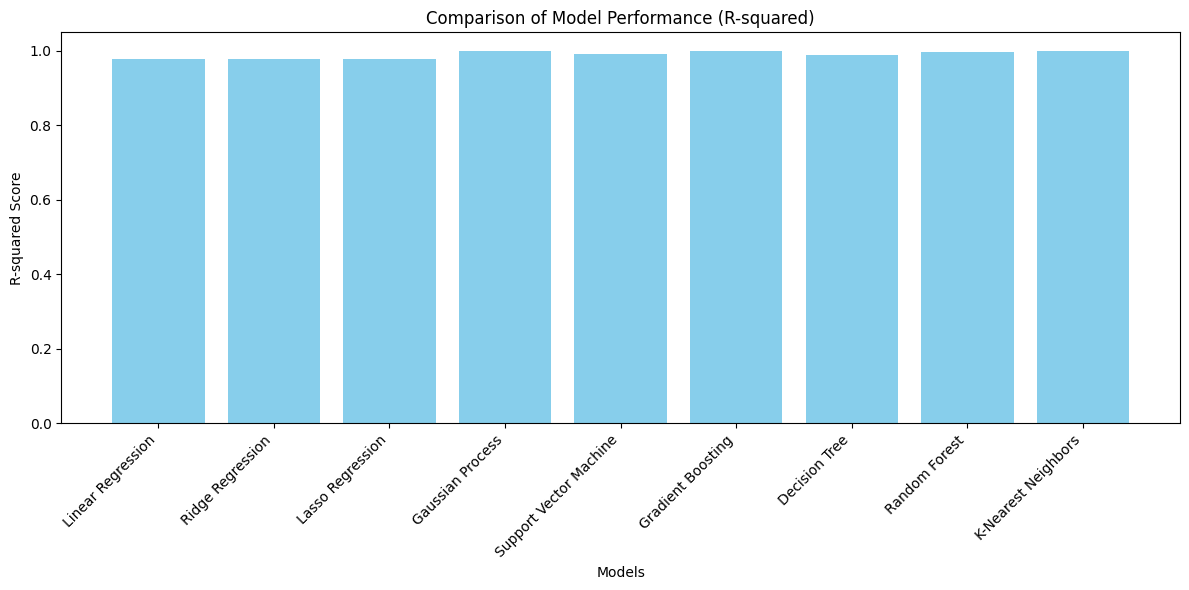

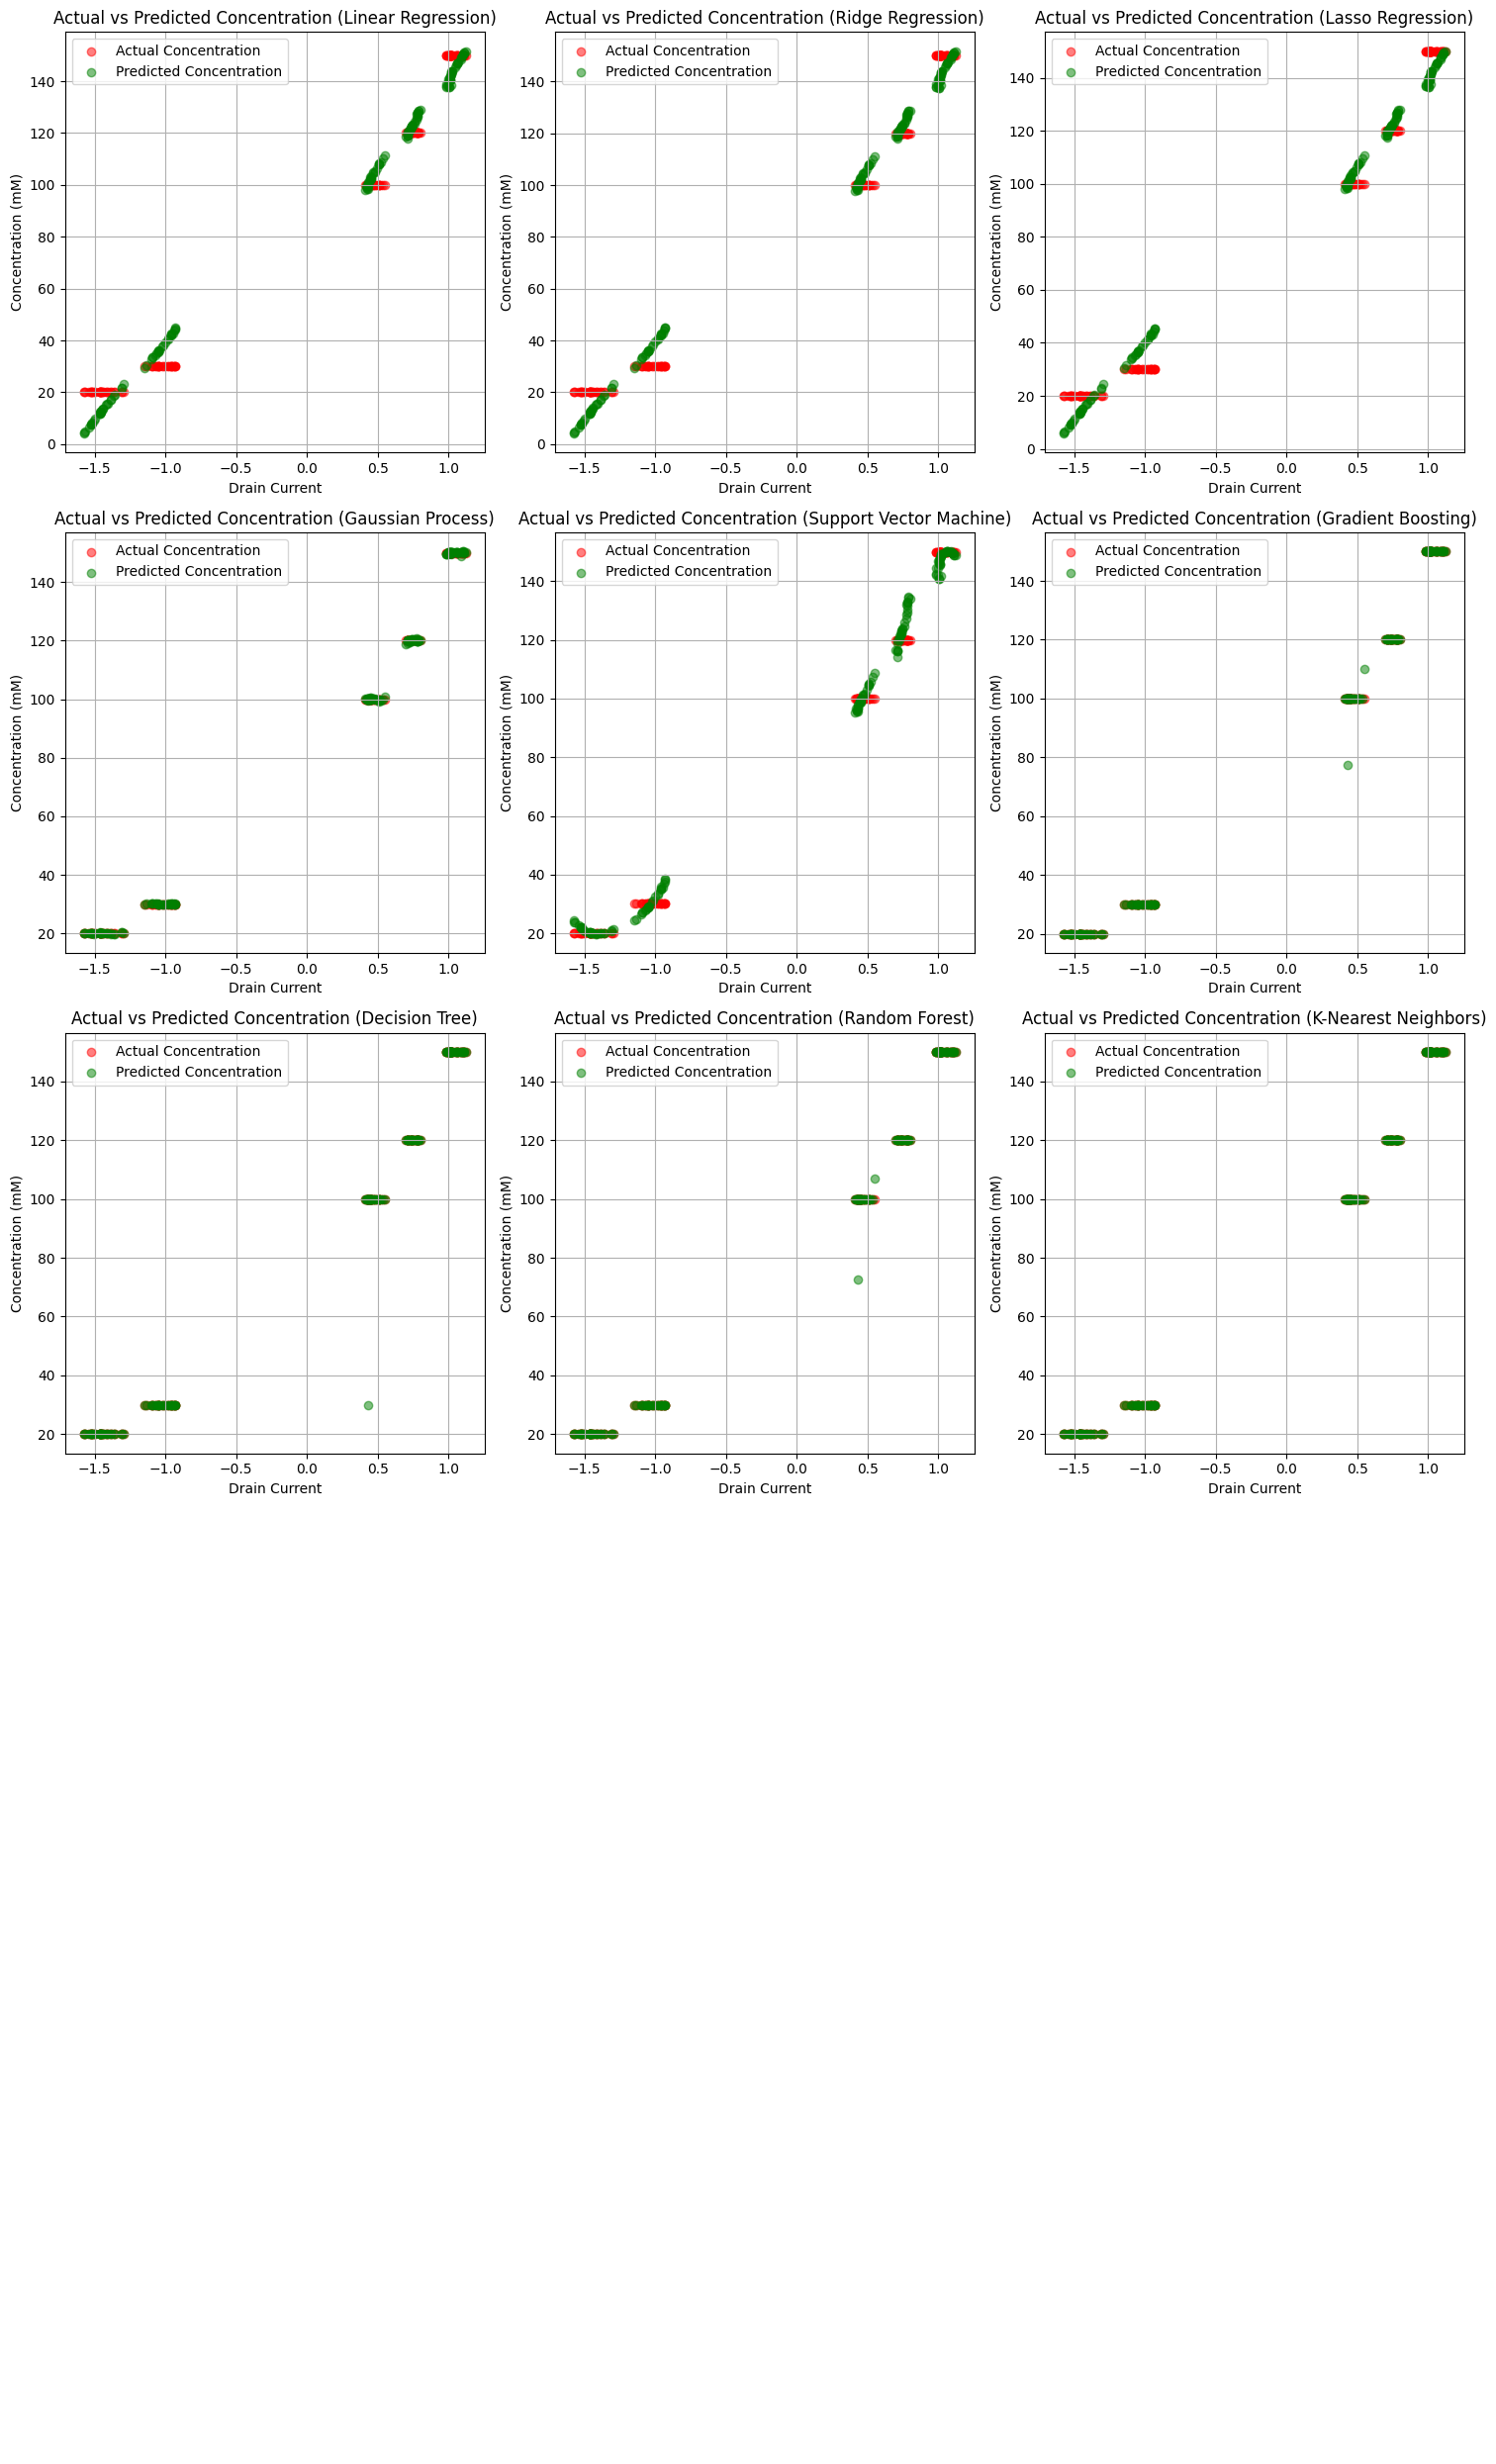

In [ ]:
X = data[['Gate Time','Drain Current']]  # Features
y = data['Concentration (mM)']  # Target variable

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
# X_train_resampled_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)


from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from imblearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Train different models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(),
    'Gaussian Process': GaussianProcessRegressor(),
    'Support Vector Machine': SVR(),
    'Gradient Boosting': GradientBoostingRegressor(),
    'Decision Tree': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor(),
    'K-Nearest Neighbors': KNeighborsRegressor()
}

model_names = []
r2_scores = []
predictions = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)  # Calculate RMSE from MSE
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    r2_scores.append(r2)
    model_names.append(name)
    predictions.append(y_pred)

    print(f'{name}:')
    print(f'Mean Squared Error: {mse}')
    print(f'Root Mean Squared Error: {rmse}') # Changed label to reflect RMSE
    print(f'Mean Absolute Error: {mae}')
    print(f'R-squared: {r2}')
    print('---')

# Create the comparison plot
plt.figure(figsize=(12, 6))
plt.bar(model_names, r2_scores, color='skyblue')
plt.xlabel("Models")
plt.ylabel("R-squared Score")
plt.title("Comparison of Model Performance (R-squared)")
plt.xticks(rotation=45, ha="right")  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

num_models = len(models)
fig, axes = plt.subplots(nrows=(num_models + 1) // 2, ncols=3, figsize=(15, 5 * ((num_models + 1) // 2)))
axes = axes.flatten()  # Flatten the axes array for easier iteration

for i, (name, model) in enumerate(models.items()):
    y_pred = predictions[i]
    axes[i].scatter(X_test_scaled[:,1], y_test, color='red', label='Actual Concentration', alpha=0.5)
    axes[i].scatter(X_test_scaled[:,1], y_pred, color='green', label='Predicted Concentration', alpha=0.5)
    axes[i].set_xlabel('Drain Current')
    axes[i].set_ylabel('Concentration (mM)')
    axes[i].set_title(f'Actual vs Predicted Concentration ({name})')
    axes[i].legend()
    axes[i].grid()

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

# Unsupervised Algorithms

In [ ]:
# from sklearn.decomposition import PCA
# pca = PCA(n_components=2)
# X_pca = pca.fit_transform(X_scaled)

#WITH ALL - Gate Voltage, Gate Time and Drain Current

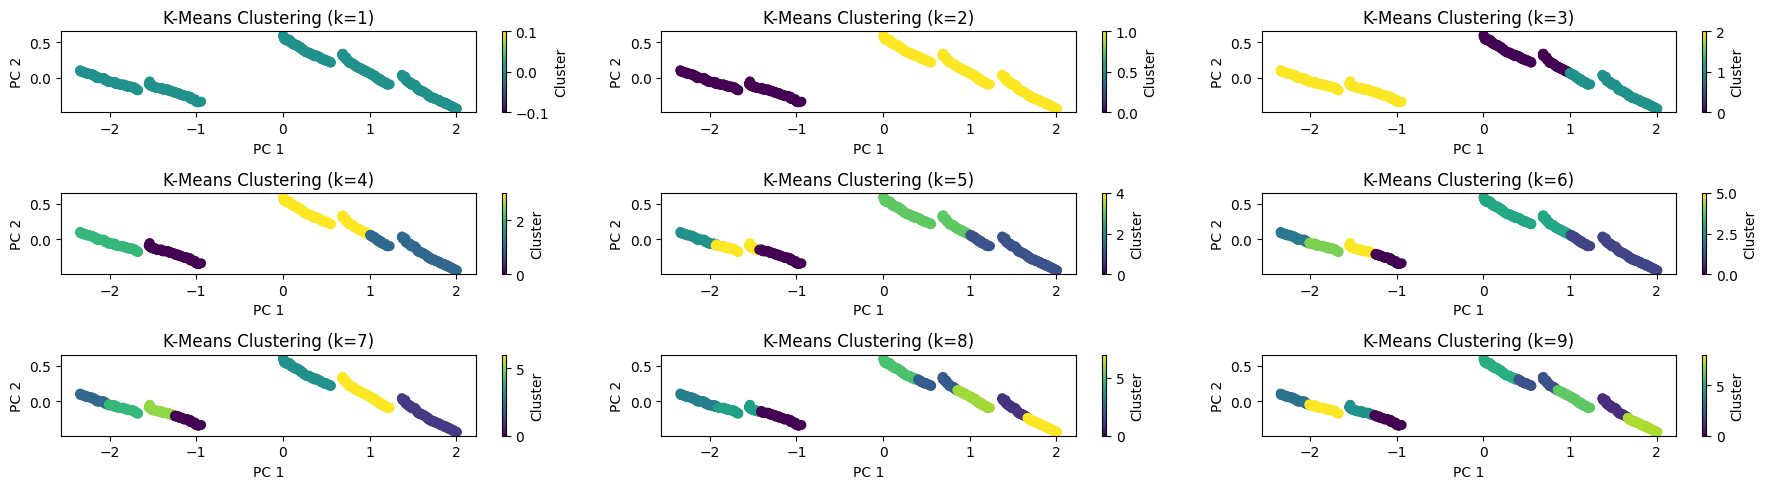

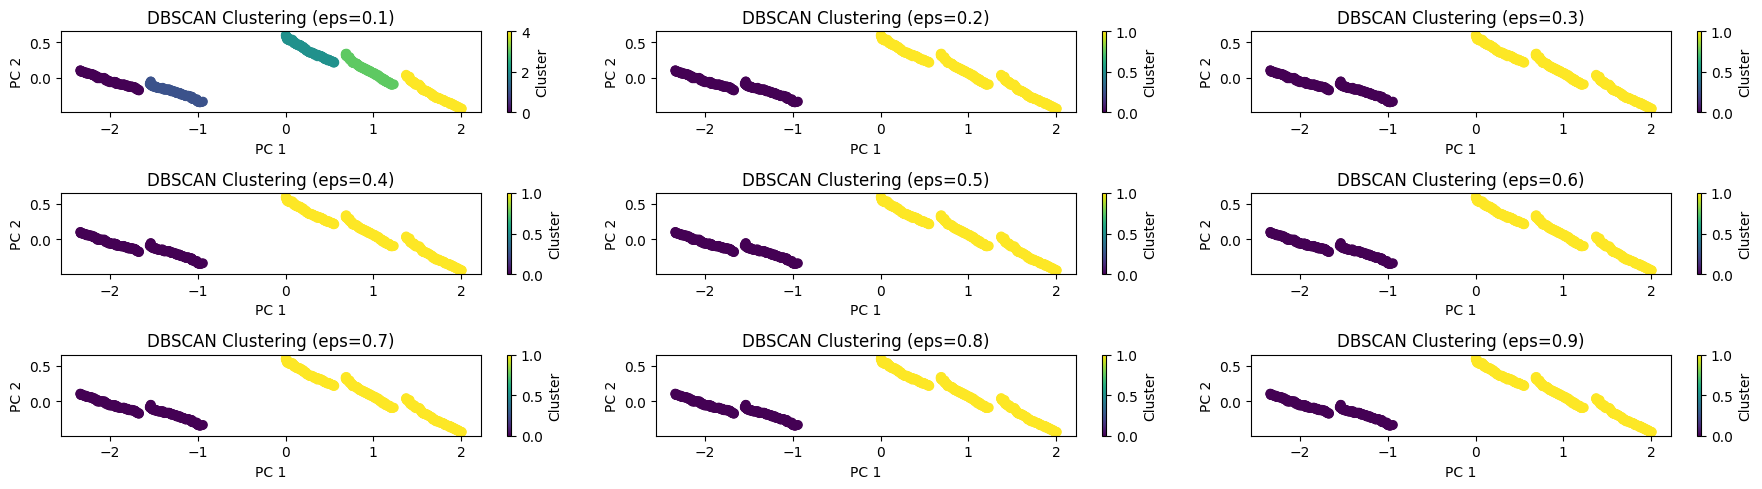

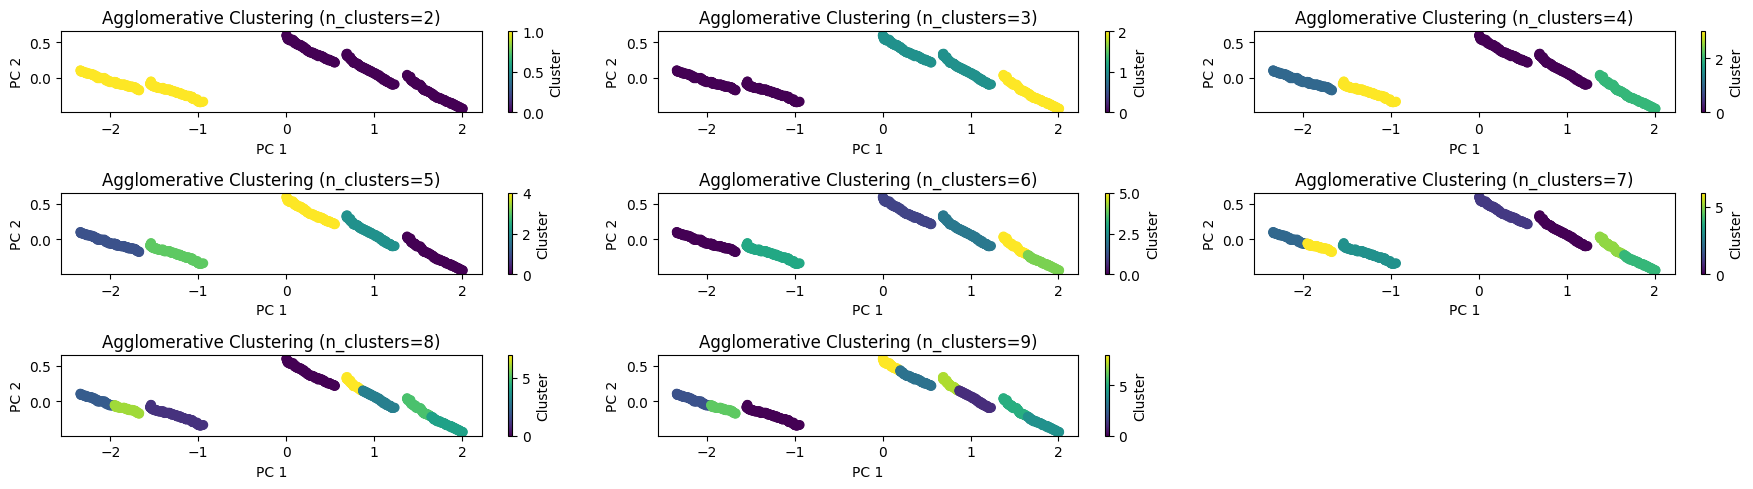

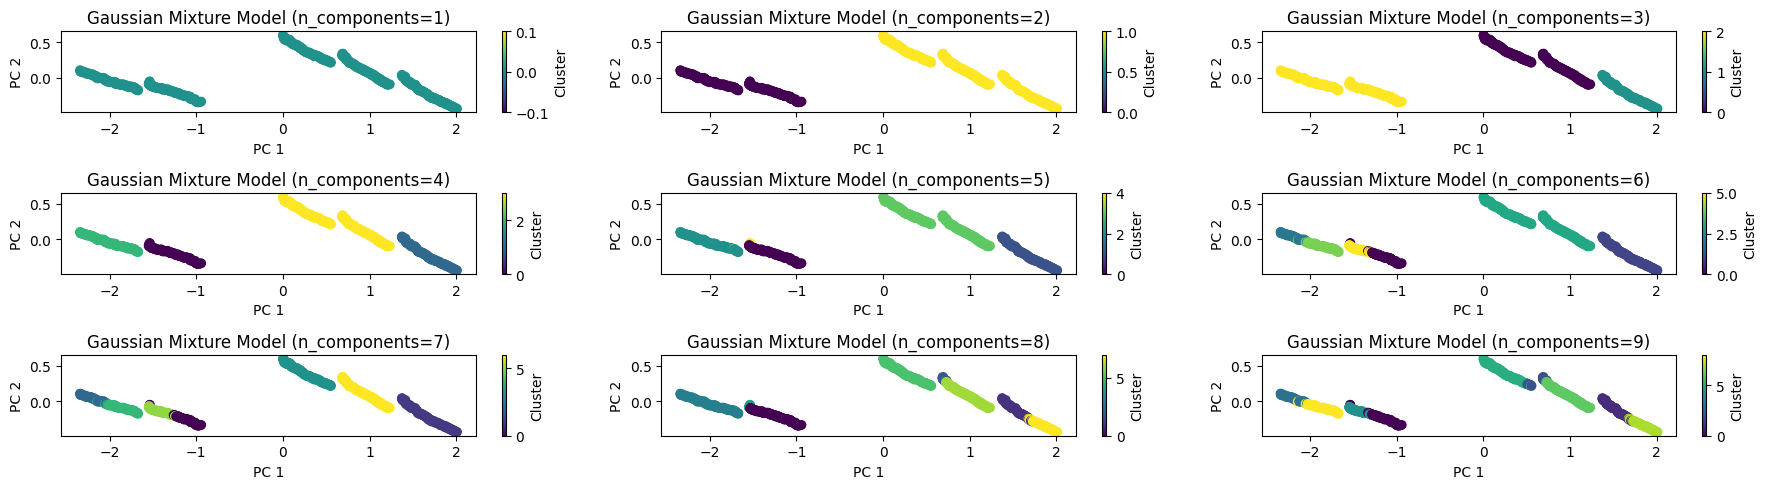

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


# Define features
X = data[['Gate Voltage','Gate Time', 'Drain Current']]  # Using Gate Time and Drain Current for clustering

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Visualize results for optimal model after PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

model_names_un = ['K-Means', 'DBSCAN', 'Hierarchical', 'Gaussian Mixture']

# Plotting the results
plt.figure(figsize=(18, 5))
for i in range(1,10):
    kmeans_optimal = KMeans(n_clusters=i, random_state=42)
    kmeans_labels_optimal = kmeans_optimal.fit_predict(X_pca)
    plt.subplot(3, 3, i)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels_optimal, cmap='viridis')
    plt.xlabel('PC 1')
    plt.ylabel('PC 2')
    plt.title(f'K-Means Clustering (k={i})')
    plt.colorbar(label='Cluster')
plt.tight_layout()
plt.show()

# Plotting the results for DBSCAN
plt.figure(figsize=(18, 5))
for eps in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    dbscan_optimal = DBSCAN(eps=eps, min_samples=5)
    dbscan_labels_optimal = dbscan_optimal.fit_predict(X_pca)
    plt.subplot(3, 3, int(eps*10))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels_optimal, cmap='viridis')
    plt.xlabel('PC 1')
    plt.ylabel('PC 2')
    plt.title(f'DBSCAN Clustering (eps={eps})')
    plt.colorbar(label='Cluster')
plt.tight_layout()
plt.show()

# Plotting the results for Agglomerative Clustering
plt.figure(figsize=(18, 5))
for i in range(2,10):
    agglo_optimal = AgglomerativeClustering(n_clusters=i)
    agglo_labels_optimal = agglo_optimal.fit_predict(X_pca)
    plt.subplot(3, 3, i-1)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agglo_labels_optimal, cmap='viridis')
    plt.xlabel('PC 1')
    plt.ylabel('PC 2')
    plt.title(f'Agglomerative Clustering (n_clusters={i})')
    plt.colorbar(label='Cluster')
plt.tight_layout()
plt.show()

# Plotting the results for Gaussian Mixture Model
plt.figure(figsize=(18, 5))
for i in range(1,10):
    gmm_optimal = GaussianMixture(n_components=i, random_state=42)
    gmm_labels_optimal = gmm_optimal.fit_predict(X_pca)
    plt.subplot(3, 3, i)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=gmm_labels_optimal, cmap='viridis')
    plt.xlabel('PC 1')
    plt.ylabel('PC 2')
    plt.title(f'Gaussian Mixture Model (n_components={i})')
    plt.colorbar(label='Cluster')
plt.tight_layout()
plt.show()

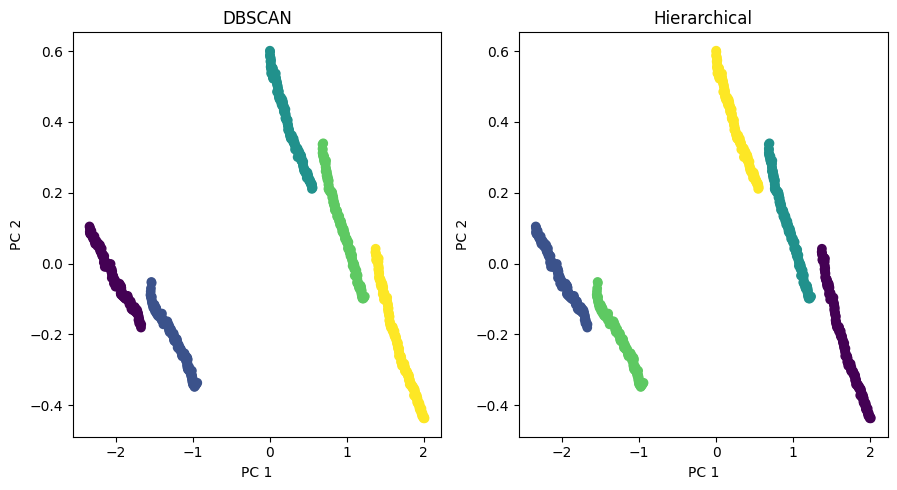

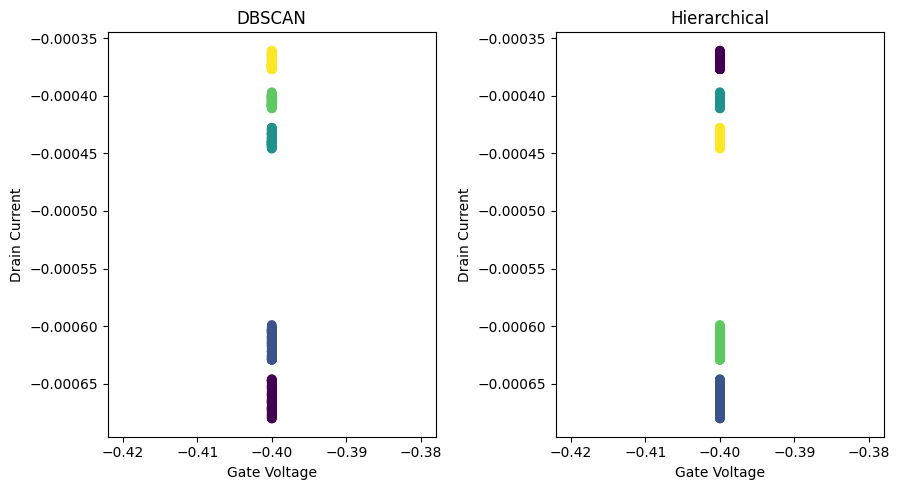

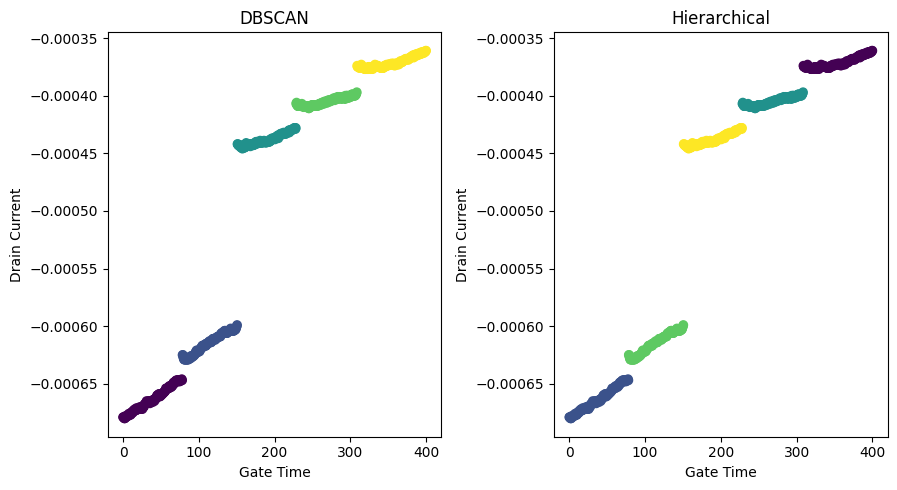

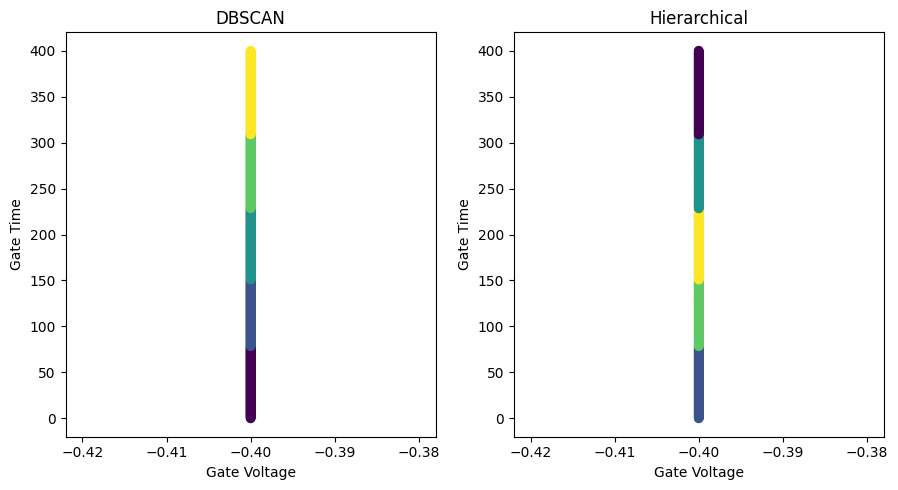

In [ ]:
#Optimal Models
model_names_un = ['DBSCAN', 'Hierarchical']#['K-Means', 'DBSCAN', 'Hierarchical', 'Gaussian Mixture']
predictions_un = []

# K-Means Clustering
# kmeans = KMeans(n_clusters=5, random_state=42)
# kmeans_labels = kmeans.fit_predict(X_pca)
# predictions_un.append(kmeans_labels)

# DBSCAN Clustering
dbscan = DBSCAN(eps=0.1, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_pca)
predictions_un.append(dbscan_labels)

# Hierarchical Clustering
agglo = AgglomerativeClustering(n_clusters=5)
agglo_labels = agglo.fit_predict(X_pca)
predictions_un.append(agglo_labels)

# Gaussian Mixture Model
# gmm = GaussianMixture(n_components=5, random_state=42) # Adjust n_components as needed
# gmm_labels = gmm.fit_predict(X_pca)
# predictions_un.append(gmm_labels)

# Apply PCA for visualization
# pca = PCA(n_components=2)
# X_pca = pca.fit_transform(X_scaled)

# Plotting the results
plt.figure(figsize=(18, 5))
for i, name in enumerate(model_names_un):
    plt.subplot(1, 4, i + 1)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=predictions_un[i], cmap='viridis', label=name)
    plt.title(name)
    plt.xlabel('PC 1')
    plt.ylabel('PC 2')
plt.tight_layout()
plt.show()

# Plotting the results
plt.figure(figsize=(18, 5))
for i, name in enumerate(model_names_un):
    plt.subplot(1, 4, i + 1)
    plt.scatter(data['Gate Voltage'], data['Drain Current'], c=predictions_un[i], cmap='viridis', label=name)
    plt.title(name)
    plt.xlabel('Gate Voltage')
    plt.ylabel('Drain Current')
plt.tight_layout()
plt.show()

# Plotting the results
plt.figure(figsize=(18, 5))
for i, name in enumerate(model_names_un):
    plt.subplot(1, 4, i + 1)
    plt.scatter(data['Gate Time'], data['Drain Current'], c=predictions_un[i], cmap='viridis', label=name)
    plt.title(name)
    plt.xlabel('Gate Time')
    plt.ylabel('Drain Current')
plt.tight_layout()
plt.show()

# Plotting the results
plt.figure(figsize=(18, 5))
for i, name in enumerate(model_names_un):
    plt.subplot(1, 4, i + 1)
    plt.scatter(data['Gate Voltage'], data['Gate Time'], c=predictions_un[i], cmap='viridis', label=name)
    plt.title(name)
    plt.xlabel('Gate Voltage')
    plt.ylabel('Gate Time')
plt.tight_layout()
plt.show()

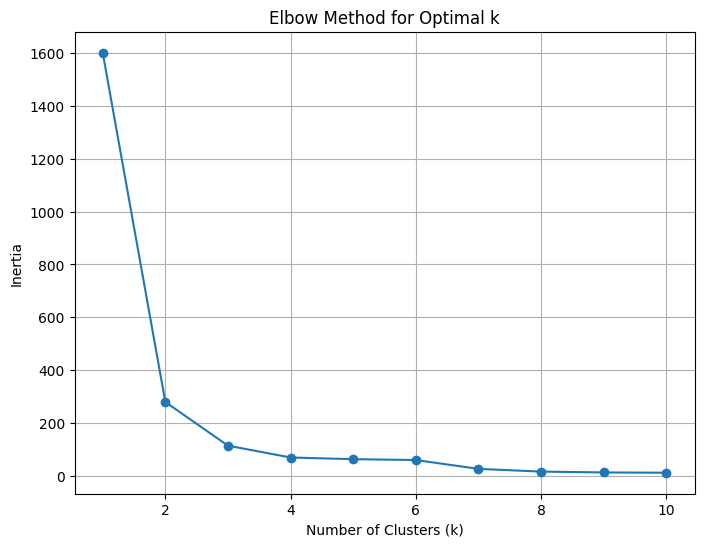

In [ ]:
# Tuning KMeans parameters (example)
inertia_values = []
for k in range(1, 11):  # Test k values from 1 to 10
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pca)
    inertia_values.append(kmeans.inertia_)

# Plotting the elbow method
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), inertia_values, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()

#With Gate Time and Drain Current

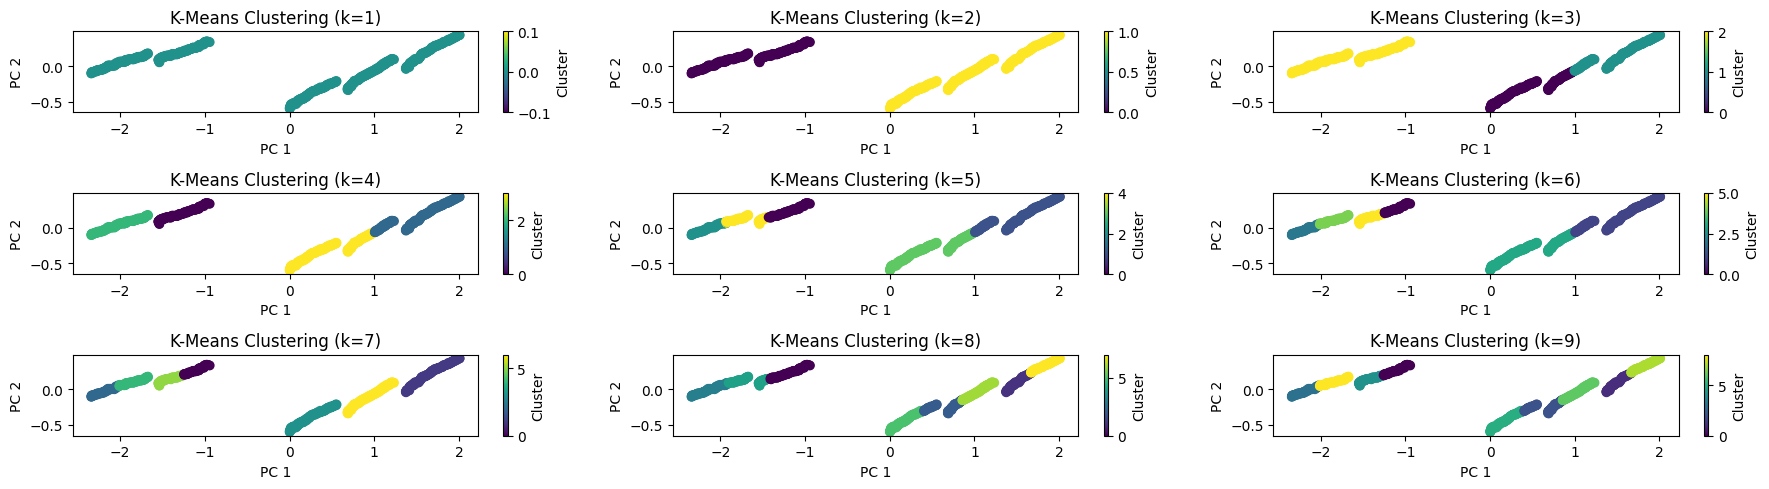

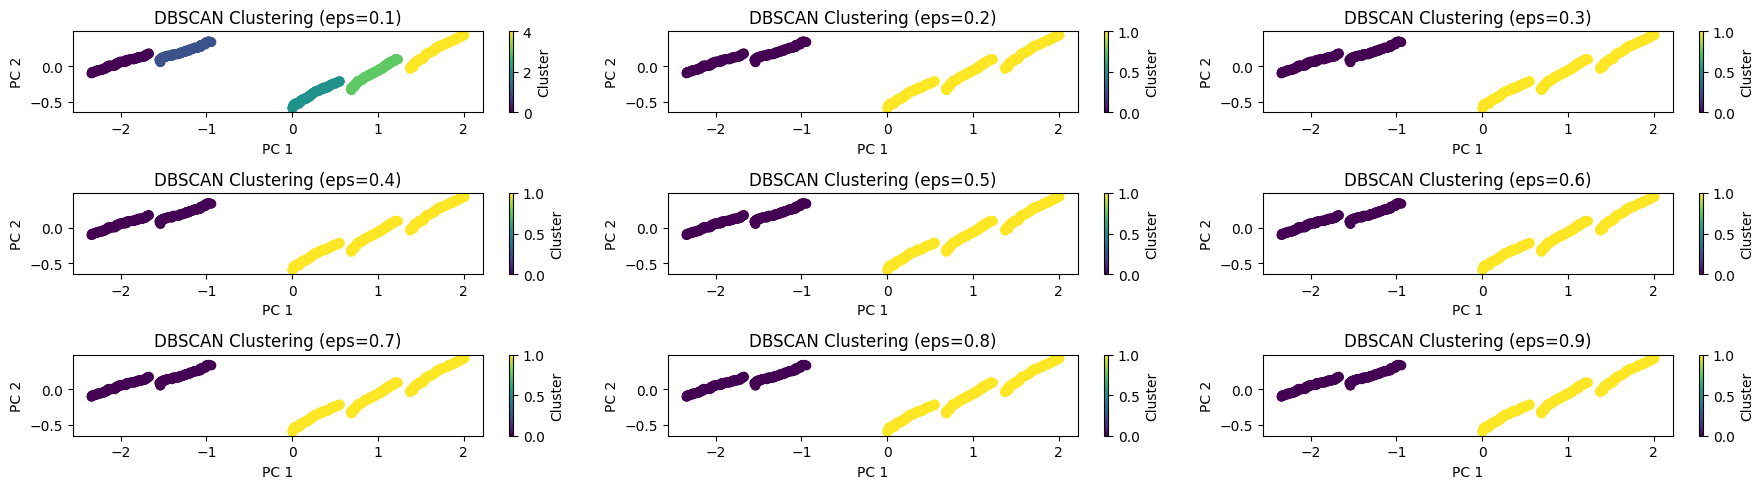

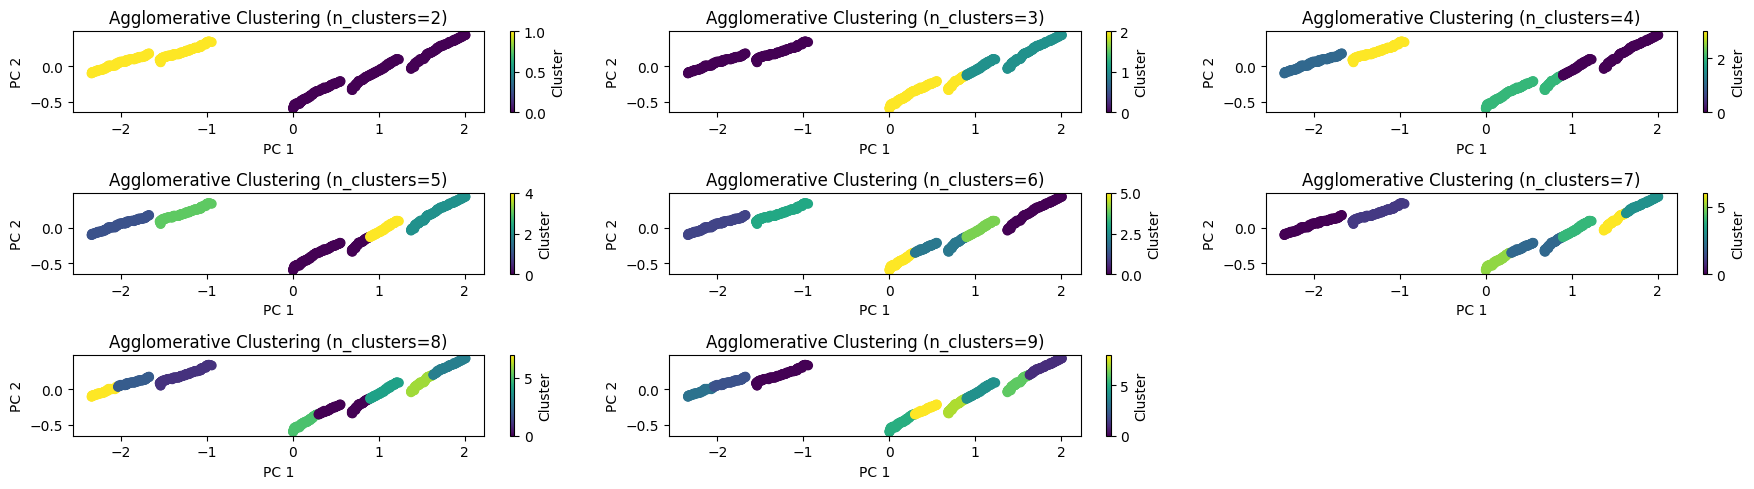

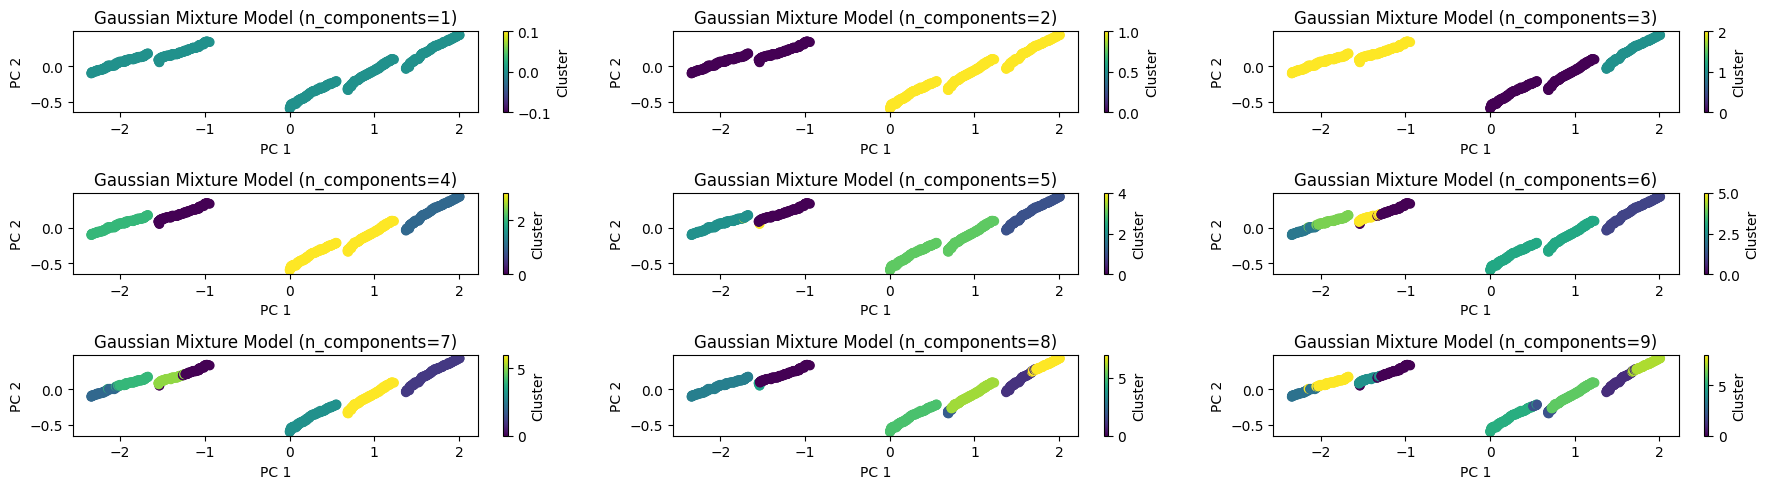

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


# Define features
X = data[['Gate Time', 'Drain Current']]  # Using Gate Time and Drain Current for clustering

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Visualize results for optimal model after PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

model_names_un = ['K-Means', 'DBSCAN', 'Hierarchical', 'Gaussian Mixture']

# Plotting the results
plt.figure(figsize=(18, 5))
for i in range(1,10):
    kmeans_optimal = KMeans(n_clusters=i, random_state=42)
    kmeans_labels_optimal = kmeans_optimal.fit_predict(X_pca)
    plt.subplot(3, 3, i)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels_optimal, cmap='viridis')
    plt.xlabel('PC 1')
    plt.ylabel('PC 2')
    plt.title(f'K-Means Clustering (k={i})')
    plt.colorbar(label='Cluster')
plt.tight_layout()
plt.show()

# Plotting the results for DBSCAN
plt.figure(figsize=(18, 5))
for eps in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    dbscan_optimal = DBSCAN(eps=eps, min_samples=5)
    dbscan_labels_optimal = dbscan_optimal.fit_predict(X_pca)
    plt.subplot(3, 3, int(eps*10))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels_optimal, cmap='viridis')
    plt.xlabel('PC 1')
    plt.ylabel('PC 2')
    plt.title(f'DBSCAN Clustering (eps={eps})')
    plt.colorbar(label='Cluster')
plt.tight_layout()
plt.show()

# Plotting the results for Agglomerative Clustering
plt.figure(figsize=(18, 5))
for i in range(2,10):
    agglo_optimal = AgglomerativeClustering(n_clusters=i)
    agglo_labels_optimal = agglo_optimal.fit_predict(X_pca)
    plt.subplot(3, 3, i-1)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agglo_labels_optimal, cmap='viridis')
    plt.xlabel('PC 1')
    plt.ylabel('PC 2')
    plt.title(f'Agglomerative Clustering (n_clusters={i})')
    plt.colorbar(label='Cluster')
plt.tight_layout()
plt.show()

# Plotting the results for Gaussian Mixture Model
plt.figure(figsize=(18, 5))
for i in range(1,10):
    gmm_optimal = GaussianMixture(n_components=i, random_state=42)
    gmm_labels_optimal = gmm_optimal.fit_predict(X_pca)
    plt.subplot(3, 3, i)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=gmm_labels_optimal, cmap='viridis')
    plt.xlabel('PC 1')
    plt.ylabel('PC 2')
    plt.title(f'Gaussian Mixture Model (n_components={i})')
    plt.colorbar(label='Cluster')
plt.tight_layout()
plt.show()

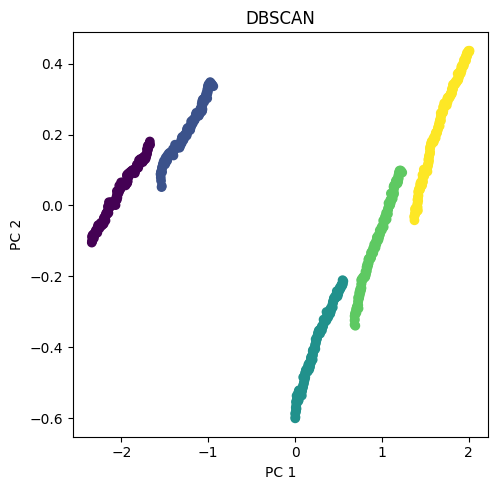

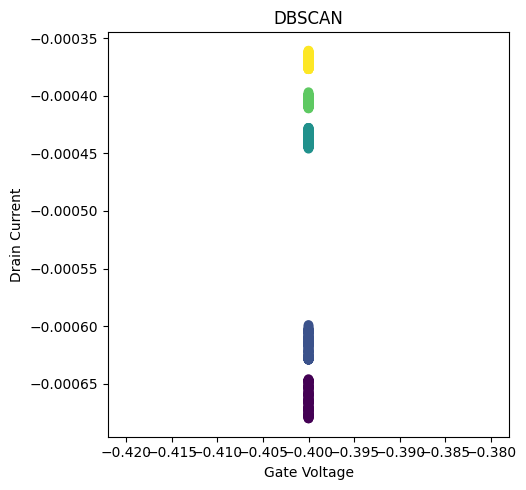

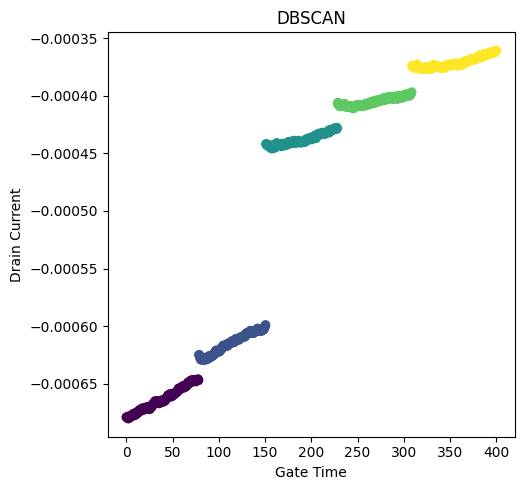

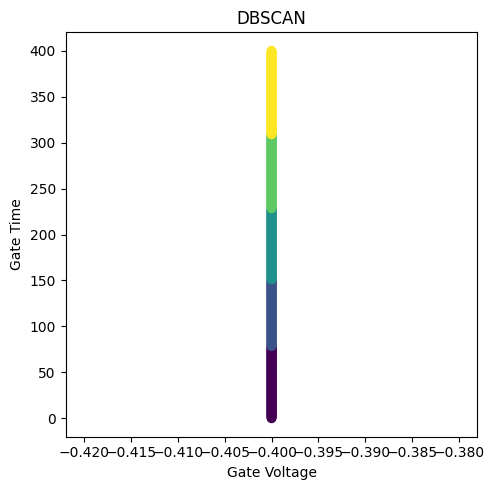

In [ ]:
#Optimal Models
# model_names_un = ['K-Means', 'DBSCAN', 'Hierarchical', 'Gaussian Mixture']
predictions_un = []

# K-Means Clustering
# kmeans = KMeans(n_clusters=5, random_state=42)
# kmeans_labels = kmeans.fit_predict(X_pca)
# predictions_un.append(kmeans_labels)

# DBSCAN Clustering
dbscan = DBSCAN(eps=0.1, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_pca)
predictions_un.append(dbscan_labels)

# Hierarchical Clustering
# agglo = AgglomerativeClustering(n_clusters=5)
# agglo_labels = agglo.fit_predict(X_pca)
# predictions_un.append(agglo_labels)

# Gaussian Mixture Model
# gmm = GaussianMixture(n_components=5, random_state=42) # Adjust n_components as needed
# gmm_labels = gmm.fit_predict(X_pca)
# predictions_un.append(gmm_labels)

# Apply PCA for visualization
# pca = PCA(n_components=2)
# X_pca = pca.fit_transform(X_scaled)

# Plotting the results
plt.figure(figsize=(18, 5))
for i, name in enumerate(model_names_un[1:2]):
    plt.subplot(1, 4, i + 1)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=predictions_un[i], cmap='viridis', label=name)
    plt.title(name)
    plt.xlabel('PC 1')
    plt.ylabel('PC 2')
plt.tight_layout()
plt.show()

# Plotting the results
plt.figure(figsize=(18, 5))
for i, name in enumerate(model_names_un[1:2]):
    plt.subplot(1, 4, i + 1)
    plt.scatter(data['Gate Voltage'], data['Drain Current'], c=predictions_un[i], cmap='viridis', label=name)
    plt.title(name)
    plt.xlabel('Gate Voltage')
    plt.ylabel('Drain Current')
plt.tight_layout()
plt.show()

# Plotting the results
plt.figure(figsize=(18, 5))
for i, name in enumerate(model_names_un[1:2]):
    plt.subplot(1, 4, i + 1)
    plt.scatter(data['Gate Time'], data['Drain Current'], c=predictions_un[i], cmap='viridis', label=name)
    plt.title(name)
    plt.xlabel('Gate Time')
    plt.ylabel('Drain Current')
plt.tight_layout()
plt.show()

# Plotting the results
plt.figure(figsize=(18, 5))
for i, name in enumerate(model_names_un[1:2]):
    plt.subplot(1, 4, i + 1)
    plt.scatter(data['Gate Voltage'], data['Gate Time'], c=predictions_un[i], cmap='viridis', label=name)
    plt.title(name)
    plt.xlabel('Gate Voltage')
    plt.ylabel('Gate Time')
plt.tight_layout()
plt.show()

#next

In [ ]:
import numpy as np
!pip install PyWavelets
import pywt
import pandas as pd

# Set random seed for reproducibility
np.random.seed(42)

# Create a noisy version of 'Drain Current'
noise_std = 0.00005  # Standard deviation of the noise
data['Noisy Drain Current'] = data['Drain Current'] + np.random.normal(0, noise_std, len(data))
# Perform wavelet denoising
# Adjust the wavelet_denoise function to match the original signal length
def wavelet_denoise(signal, wavelet='db1', level=1):
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    sigma = noise_std
    uthresh = sigma * np.sqrt(2 * np.log(len(signal)))
    coeffs[1:] = (pywt.threshold(c, value=uthresh, mode='soft') for c in coeffs[1:])
    denoised_signal = pywt.waverec(coeffs, wavelet)

    # Adjust length if needed
    return denoised_signal[:len(signal)]

# Apply wavelet denoising to 'Noisy Drain Current' and ensure it matches the DataFrame length
data['Denoised Drain Current'] = wavelet_denoise(data['Noisy Drain Current'])

# Create a new DataFrame with the denoised data and other columns
denoised_data = pd.DataFrame({
    'Gate Voltage': data['Gate Voltage'],
    'Gate Time': data['Gate Time'],
    'Drain Current': data['Denoised Drain Current'],  # Use denoised Drain Current
    'Concentration (mM)': data['Concentration (mM)']
})
# Display the new DataFrame
denoised_data.head()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 32.6 MB/s eta 0:00:00


,Gate Voltage,Gate Time,Drain Current,Concentration (mM)
0,-0.4,0.0,-0.000670,20.0
1,-0.4,0.5,-0.000670,20.0
2,-0.4,1.0,-0.000625,20.0
3,-0.4,1.5,-0.000625,20.0
4,-0.4,2.0,-0.000692,20.0


In [ ]:
# Step 1: Import required libraries
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
import pandas as pd

# Assuming 'denoised_data' is already loaded and has a 'concentration' column
# Display the first few rows to understand its structure
print(denoised_data.head())

# Step 2: Prepare data by removing the 'concentration' column for clustering
# Separate the concentration column (original labels) for later evaluation
original_labels = denoised_data['Concentration (mM)']
data_for_clustering = denoised_data.drop(columns=['Concentration (mM)'])

# Step 3: Choose and fit a clustering model (KMeans in this example)
# Define the number of clusters based on unique concentration values
num_clusters = len(original_labels.unique())  # Number of unique concentrations

# Initialize and fit KMeans model
kmeans = KMeans(n_clusters=num_clusters, random_state=0)
cluster_labels = kmeans.fit_predict(data_for_clustering)

# Step 4: Evaluate clustering performance
# Calculate the Adjusted Rand Index (ARI) and silhouette score
ari_score = adjusted_rand_score(original_labels, cluster_labels)
silhouette_avg = silhouette_score(data_for_clustering, cluster_labels)

# Display the evaluation metrics
print(f"Adjusted Rand Index (ARI): {ari_score}")
print(f"Silhouette Score: {silhouette_avg}")

# Step 5: Create a DataFrame to display clustering results
results_df = denoised_data.copy()
results_df['Predicted_Cluster'] = cluster_labels

# Display the first few rows of the results with the predicted clusters
print(results_df.head())


   Gate Voltage  Gate Time  Drain Current  Concentration (mM)
0          -0.4        0.0      -0.000670                20.0
1          -0.4        0.5      -0.000670                20.0
2          -0.4        1.0      -0.000625                20.0
3          -0.4        1.5      -0.000625                20.0
4          -0.4        2.0      -0.000692                20.0
Adjusted Rand Index (ARI): 0.8487993747397864
Silhouette Score: 0.5582238594830663
   Gate Voltage  Gate Time  Drain Current  Concentration (mM)  \
0          -0.4        0.0      -0.000670                20.0   
1          -0.4        0.5      -0.000670                20.0   
2          -0.4        1.0      -0.000625                20.0   
3          -0.4        1.5      -0.000625                20.0   
4          -0.4        2.0      -0.000692                20.0   

   Predicted_Cluster  
0                  3  
1                  3  
2                  3  
3                  3  
4                  3  


In [ ]:
results_df['Predicted_Cluster'].unique()

array([3, 1, 0, 4, 2], dtype=int32)

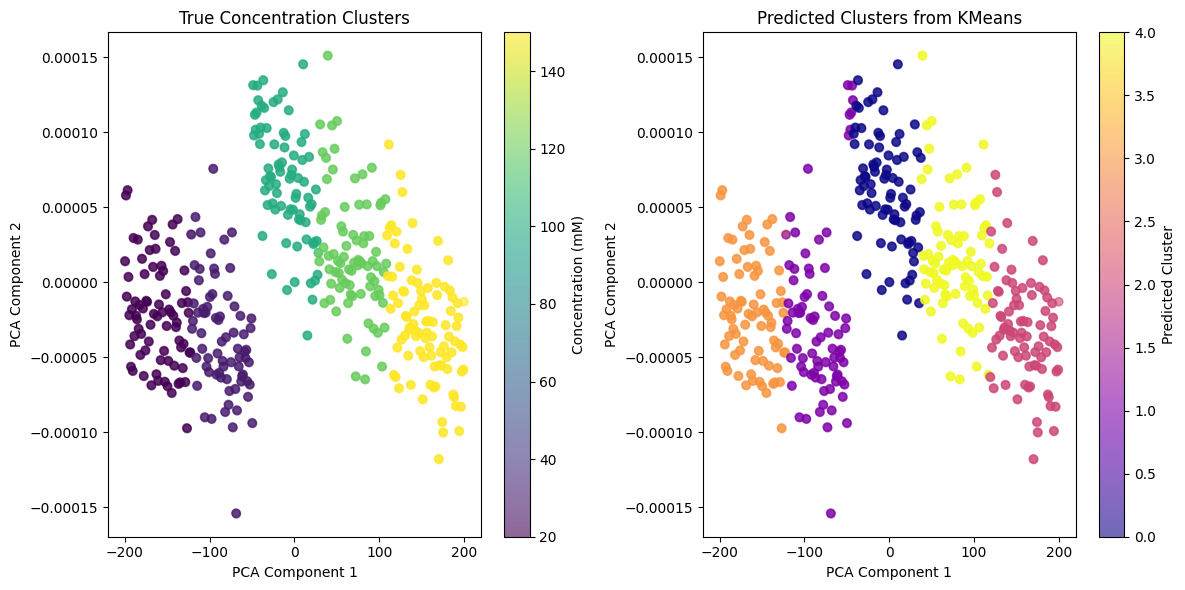

In [ ]:
# Step 1: Import required libraries for plotting and dimensionality reduction
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Assuming the previous code has already been executed
# Step 2: Dimensionality reduction using PCA to visualize in 2D
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(data_for_clustering)

# Step 3: Create a scatter plot to visualize the clusters
plt.figure(figsize=(12, 6))

# Plot the true concentration clusters
plt.subplot(1, 2, 1)
plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=original_labels, cmap='viridis', alpha=0.6)
plt.title('True Concentration Clusters')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Concentration (mM)')

# Plot the predicted clusters
plt.subplot(1, 2, 2)
plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=cluster_labels, cmap='plasma', alpha=0.6)
plt.title('Predicted Clusters from KMeans')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Predicted Cluster')

plt.tight_layout()
plt.show()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.4/374.4 kB 6.7 MB/s eta 0:00:00
   Gate Voltage1  Gate Time1  Drain Current1  Concentration (mM)1
0           -0.4         0.0       -0.000670                 20.0
1           -0.4         0.5       -0.000670                 20.0
2           -0.4         1.0       -0.000625                 20.0
3           -0.4         1.5       -0.000625                 20.0
4           -0.4         2.0       -0.000692                 20.0
Adjusted Rand Index (ARI) for Time Series Clustering: 0.8487993747397864
Silhouette Score for Time Series Clustering: 0.5582238594830663
   Gate Voltage1  Gate Time1  Drain Current1  Concentration (mM)1  \
0           -0.4         0.0       -0.000670                 20.0   
1           -0.4         0.5       -0.000670                 20.0   
2           -0.4         1.0       -0.000625                 20.0   
3           -0.4         1.5       -0.000625                 20.0   
4           -0.4         2.0       -0.0006

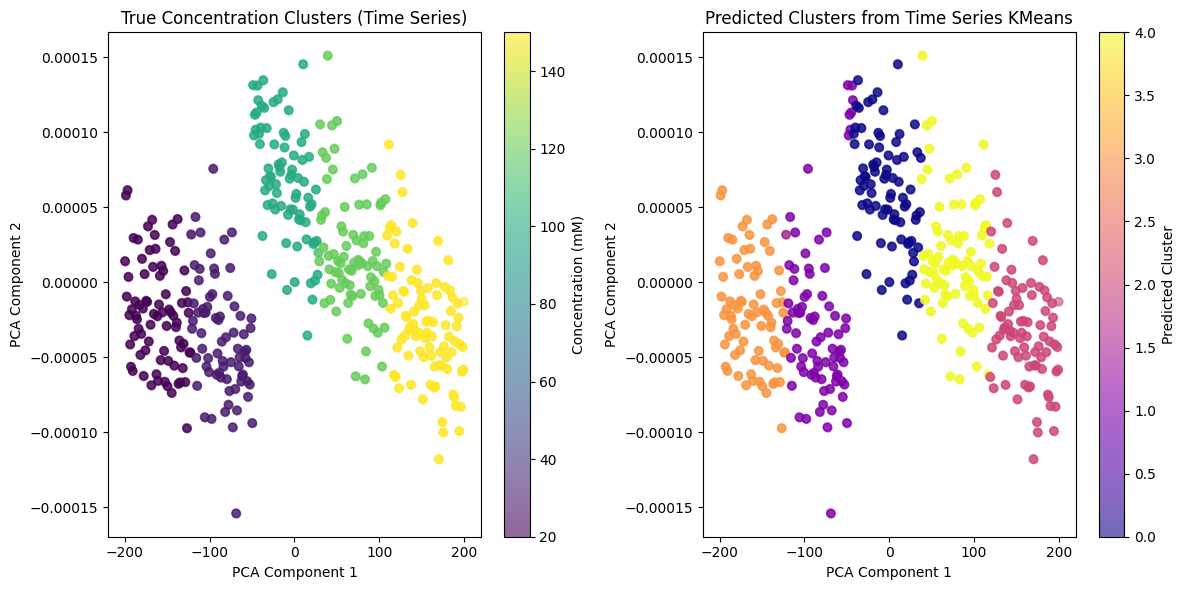

In [ ]:
import numpy as np
!pip install PyWavelets
import pywt
import pandas as pd
from sklearn.metrics import adjusted_rand_score, silhouette_score
!pip install tslearn
from tslearn.clustering import TimeSeriesKMeans
from sklearn.decomposition import PCA
# Set random seed for reproducibility
np.random.seed(42)

# Create a noisy version of 'Drain Current'
noise_std = 0.00005  # Standard deviation of the noise
data['Noisy Drain Current'] = data['Drain Current'] + np.random.normal(0, noise_std, len(data))

# Perform wavelet denoising
def wavelet_denoise(signal, wavelet='db1', level=1):
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    sigma = noise_std
    uthresh = sigma * np.sqrt(2 * np.log(len(signal)))
    coeffs[1:] = (pywt.threshold(c, value=uthresh, mode='soft') for c in coeffs[1:])
    denoised_signal1 = pywt.waverec(coeffs, wavelet)

    return denoised_signal1[:len(signal)]

# Apply wavelet denoising to 'Noisy Drain Current'
data['Denoised Drain Current1'] = wavelet_denoise(data['Noisy Drain Current'])

# Create a new DataFrame with the denoised data and other columns
denoised_data1 = pd.DataFrame({
    'Gate Voltage1': data['Gate Voltage'],
    'Gate Time1': data['Gate Time'],
    'Drain Current1': data['Denoised Drain Current1'],
    'Concentration (mM)1': data['Concentration (mM)']
})

# Display the new DataFrame
print(denoised_data1.head())

# Step 1: Import required libraries for time series clustering
from tslearn.clustering import TimeSeriesKMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score

# Step 2: Prepare data by removing the 'Concentration (mM)' column for clustering
original_labels1 = denoised_data1['Concentration (mM)1']
data_for_clustering1 = denoised_data1.drop(columns=['Concentration (mM)1'])

# Step 3: Reshape data for time series clustering (if necessary)
# Assuming the data is 2D, we'll use a 3D shape for TimeSeriesKMeans
data_for_clustering1_reshaped = data_for_clustering1.values.reshape(data_for_clustering1.shape[0], data_for_clustering1.shape[1], 1)

# Step 4: Choose and fit a time series clustering model (TimeSeriesKMeans in this example)
num_clusters1 = len(original_labels1.unique())  # Number of unique concentrations

# Initialize and fit TimeSeriesKMeans model
ts_kmeans1 = TimeSeriesKMeans(n_clusters=num_clusters1, metric="euclidean", random_state=0)
cluster_labels1 = ts_kmeans1.fit_predict(data_for_clustering1_reshaped)

# Step 5: Evaluate clustering performance
ari_score1 = adjusted_rand_score(original_labels1, cluster_labels1)
silhouette_avg1 = silhouette_score(data_for_clustering1_reshaped.reshape(data_for_clustering1.shape[0], -1), cluster_labels1)

# Display the evaluation metrics
print(f"Adjusted Rand Index (ARI) for Time Series Clustering: {ari_score1}")
print(f"Silhouette Score for Time Series Clustering: {silhouette_avg1}")

# Step 6: Create a DataFrame to display clustering results
results_df1 = denoised_data1.copy()
results_df1['Predicted_Cluster1'] = cluster_labels1

# Display the first few rows of the results with the predicted clusters
print(results_df1.head())

# Step 7: Dimensionality reduction using PCA to visualize in 2D
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reshape data for PCA
reduced_data1 = PCA(n_components=2).fit_transform(data_for_clustering1)

# Create a scatter plot to visualize the clusters
plt.figure(figsize=(12, 6))

# Plot the true concentration clusters
plt.subplot(1, 2, 1)
plt.scatter(reduced_data1[:, 0], reduced_data1[:, 1], c=original_labels1, cmap='viridis', alpha=0.6)
plt.title('True Concentration Clusters (Time Series)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Concentration (mM)')

# Plot the predicted clusters
plt.subplot(1, 2, 2)
plt.scatter(reduced_data1[:, 0], reduced_data1[:, 1], c=cluster_labels1, cmap='plasma', alpha=0.6)
plt.title('Predicted Clusters from Time Series KMeans')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Predicted Cluster')

plt.tight_layout()
plt.show()


Normal Clustering - Adjusted Rand Index (ARI): 0.6666177859207334
Normal Clustering - Silhouette Score: 0.5512850142029071
Time Series Clustering - Adjusted Rand Index (ARI): 0.6666177859207334
Time Series Clustering - Silhouette Score: 0.5512850142029071
     Gate Voltage  Gate Time  Drain Current  Concentration (mM)  \
616          -0.4      308.0      -0.000377               120.0   
329          -0.4      164.5      -0.000411               100.0   
342          -0.4      171.0      -0.000450               100.0   
394          -0.4      197.0      -0.000420               100.0   
79           -0.4       39.5      -0.000712                20.0   

     Predicted_Cluster_normal  Predicted_Cluster_ts  
616                       2.0                   NaN  
329                       1.0                   NaN  
342                       0.0                   NaN  
394                       0.0                   NaN  
79                        3.0                   NaN  


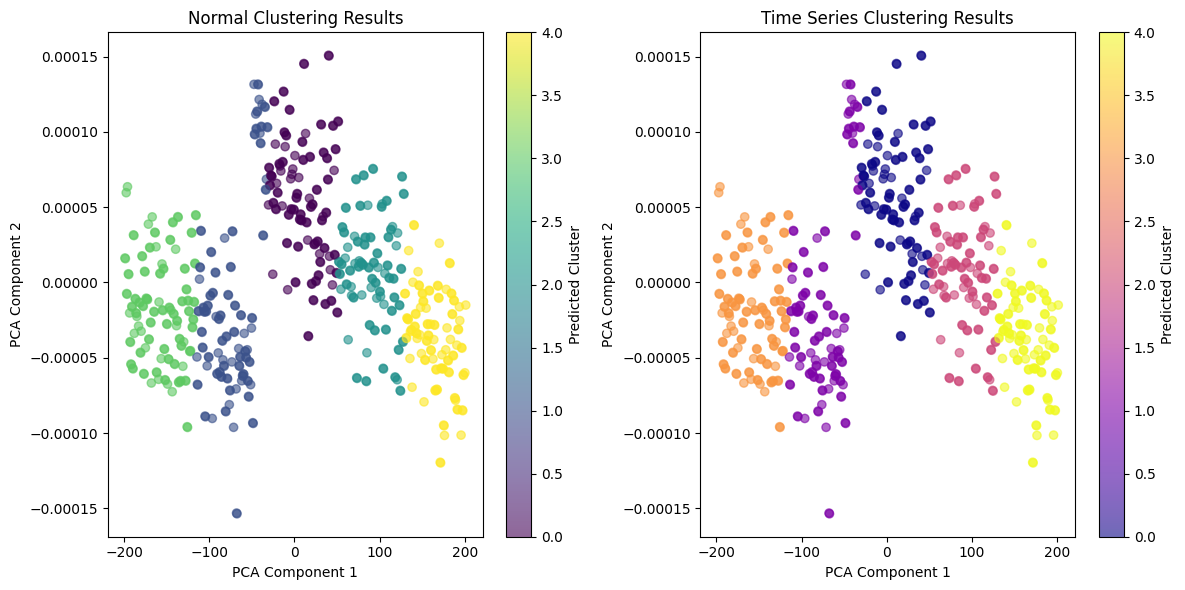

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pywt
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

# Set random seed for reproducibility
np.random.seed(42)

# Create a noisy version of 'Drain Current'
noise_std = 0.00005  # Standard deviation of the noise
data['Noisy Drain Current'] = data['Drain Current'] + np.random.normal(0, noise_std, len(data))

# Perform wavelet denoising
def wavelet_denoise(signal, wavelet='db1', level=1):
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    sigma = noise_std
    uthresh = sigma * np.sqrt(2 * np.log(len(signal)))
    coeffs[1:] = (pywt.threshold(c, value=uthresh, mode='soft') for c in coeffs[1:])
    denoised_signal = pywt.waverec(coeffs, wavelet)
    return denoised_signal[:len(signal)]

# Apply wavelet denoising to 'Noisy Drain Current'
data['Denoised Drain Current'] = wavelet_denoise(data['Noisy Drain Current'])

# Create a new DataFrame with the denoised data and other columns
denoised_data = pd.DataFrame({
    'Gate Voltage': data['Gate Voltage'],
    'Gate Time': data['Gate Time'],
    'Drain Current': data['Denoised Drain Current'],
    'Concentration (mM)': data['Concentration (mM)']
})

# Step 1: Train-test split for normal clustering
train_data, test_data = train_test_split(denoised_data, test_size=0.2, random_state=42)

# Normal Clustering
# Prepare training data by removing the 'Concentration (mM)' column
original_labels_normal = train_data['Concentration (mM)']
data_for_clustering = train_data.drop(columns=['Concentration (mM)'])

# Fit KMeans model
num_clusters_normal = len(original_labels_normal.unique())
kmeans_normal = KMeans(n_clusters=num_clusters_normal, random_state=0)
cluster_labels_normal = kmeans_normal.fit_predict(data_for_clustering)

# Evaluate normal clustering performance
ari_score_normal = adjusted_rand_score(original_labels_normal, cluster_labels_normal)
silhouette_avg_normal = silhouette_score(data_for_clustering, cluster_labels_normal)

# Display evaluation metrics
print(f"Normal Clustering - Adjusted Rand Index (ARI): {ari_score_normal}")
print(f"Normal Clustering - Silhouette Score: {silhouette_avg_normal}")

# Step 2: Prepare results DataFrame for normal clustering
results_df_normal = train_data.copy()
results_df_normal['Predicted_Cluster_normal'] = cluster_labels_normal

# Step 3: Train-test split for time series clustering
# Assuming denoised_data is still available after splitting
train_data_ts, test_data_ts = train_test_split(denoised_data, test_size=0.2, random_state=42)

# Prepare training data for time series clustering
original_labels_ts = train_data_ts['Concentration (mM)']
data_for_clustering_ts = train_data_ts.drop(columns=['Concentration (mM)'])

# Fit KMeans model for time series
num_clusters_ts = len(original_labels_ts.unique())
kmeans_ts = KMeans(n_clusters=num_clusters_ts, random_state=0)
cluster_labels_ts = kmeans_ts.fit_predict(data_for_clustering_ts)

# Evaluate time series clustering performance
ari_score_ts = adjusted_rand_score(original_labels_ts, cluster_labels_ts)
silhouette_avg_ts = silhouette_score(data_for_clustering_ts, cluster_labels_ts)

# Display evaluation metrics
print(f"Time Series Clustering - Adjusted Rand Index (ARI): {ari_score_ts}")
print(f"Time Series Clustering - Silhouette Score: {silhouette_avg_ts}")

# Step 4: Prepare results DataFrame for time series clustering
results_df_ts = train_data_ts.copy()
results_df_ts['Predicted_Cluster_ts'] = cluster_labels_ts

# Combine results for comparison
combined_results = pd.concat([results_df_normal, results_df_ts], axis=0)

# Display the first few rows of the combined results
print(combined_results.head())

# Step 5: Dimensionality reduction using PCA for visualization
pca_normal = PCA(n_components=2)
reduced_data_normal = pca_normal.fit_transform(data_for_clustering)

pca_ts = PCA(n_components=2)
reduced_data_ts = pca_ts.fit_transform(data_for_clustering_ts)

# Step 6: Create scatter plots for both normal and time series clustering
plt.figure(figsize=(12, 6))

# Normal clustering plot
plt.subplot(1, 2, 1)
plt.scatter(reduced_data_normal[:, 0], reduced_data_normal[:, 1], c=cluster_labels_normal, cmap='viridis', alpha=0.6)
plt.title('Normal Clustering Results')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Predicted Cluster')

# Time series clustering plot
plt.subplot(1, 2, 2)
plt.scatter(reduced_data_ts[:, 0], reduced_data_ts[:, 1], c=cluster_labels_ts, cmap='plasma', alpha=0.6)
plt.title('Time Series Clustering Results')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Predicted Cluster')

plt.tight_layout()
plt.show()


Normal Clustering - Adjusted Rand Index (ARI): 0.67
Normal Clustering - Silhouette Score: 0.55
Time Series Clustering - Adjusted Rand Index (ARI): 0.67
Time Series Clustering - Silhouette Score: 0.55
     Gate Voltage  Gate Time  Drain Current  Concentration (mM)  \
616          -0.4      308.0      -0.000377               120.0   
329          -0.4      164.5      -0.000411               100.0   
342          -0.4      171.0      -0.000450               100.0   
394          -0.4      197.0      -0.000420               100.0   
79           -0.4       39.5      -0.000712                20.0   

     Predicted_Cluster_normal  Predicted_Cluster_ts  
616                       2.0                   NaN  
329                       1.0                   NaN  
342                       0.0                   NaN  
394                       0.0                   NaN  
79                        3.0                   NaN  


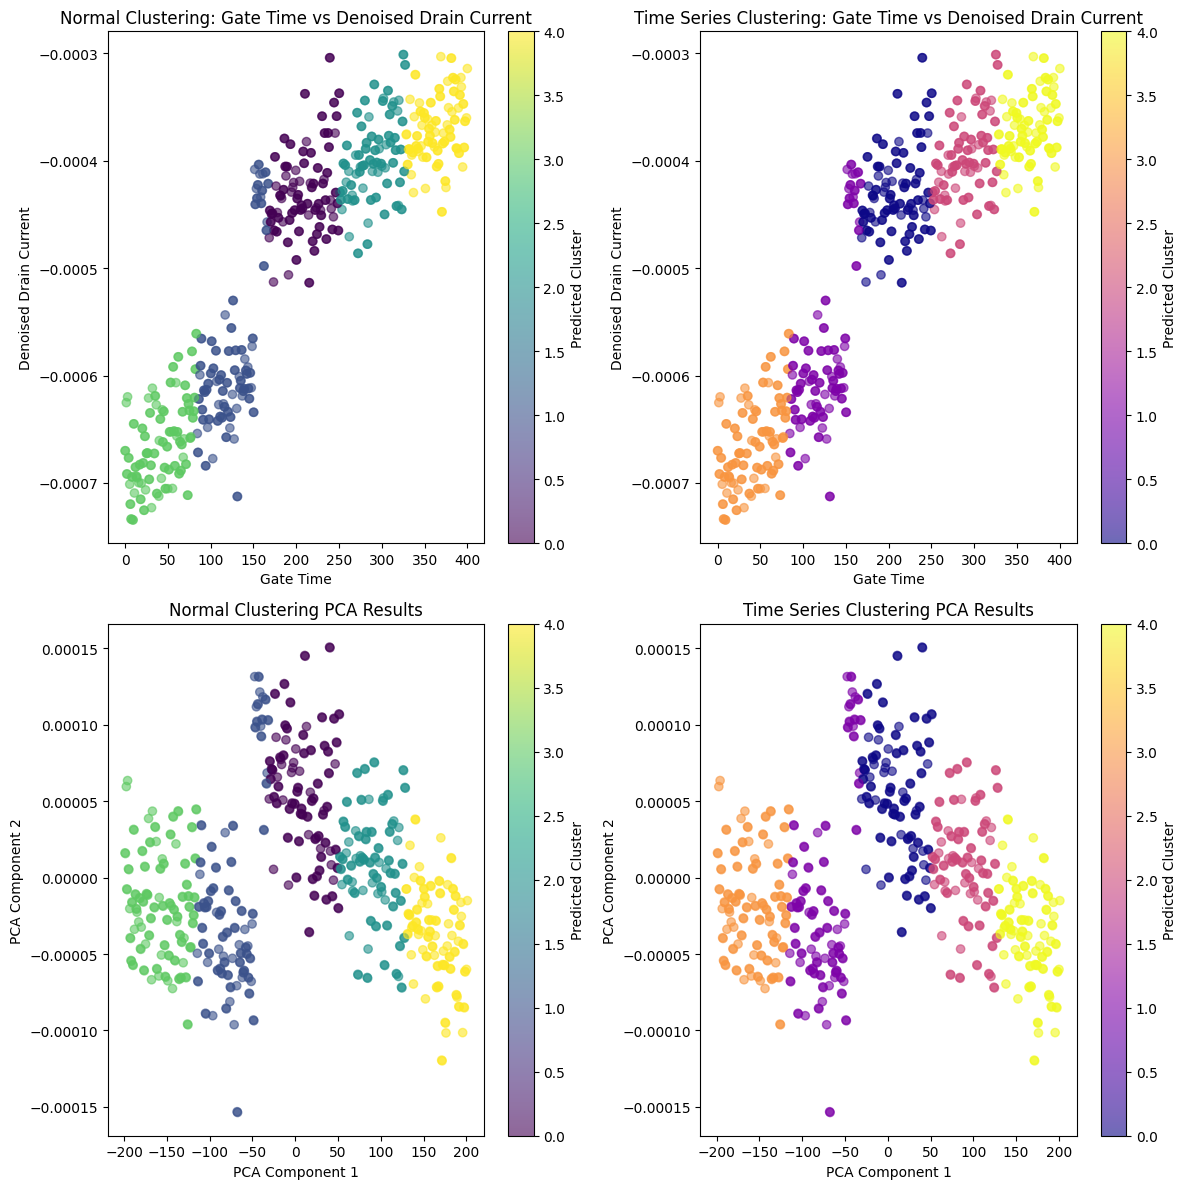

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pywt
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

# Set random seed for reproducibility
np.random.seed(42)

# Create a noisy version of 'Drain Current'
noise_std = 0.00005  # Standard deviation of the noise
data['Noisy Drain Current'] = data['Drain Current'] + np.random.normal(0, noise_std, len(data))

# Perform wavelet denoising
def wavelet_denoise(signal, wavelet='db1', level=1):
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    sigma = noise_std
    uthresh = sigma * np.sqrt(2 * np.log(len(signal)))
    coeffs[1:] = (pywt.threshold(c, value=uthresh, mode='soft') for c in coeffs[1:])
    denoised_signal = pywt.waverec(coeffs, wavelet)
    return denoised_signal[:len(signal)]

# Apply wavelet denoising to 'Noisy Drain Current'
data['Denoised Drain Current'] = wavelet_denoise(data['Noisy Drain Current'])

# Create a new DataFrame with the denoised data and other columns
denoised_data = pd.DataFrame({
    'Gate Voltage': data['Gate Voltage'],
    'Gate Time': data['Gate Time'],
    'Drain Current': data['Denoised Drain Current'],
    'Concentration (mM)': data['Concentration (mM)']
})

# Step 1: Train-test split for normal clustering
train_data, test_data = train_test_split(denoised_data, test_size=0.2, random_state=42)

# Normal Clustering
# Prepare training data by removing the 'Concentration (mM)' column
original_labels_normal = train_data['Concentration (mM)']
data_for_clustering = train_data.drop(columns=['Concentration (mM)'])

# Fit KMeans model
num_clusters_normal = len(original_labels_normal.unique())
kmeans_normal = KMeans(n_clusters=num_clusters_normal, random_state=0)
cluster_labels_normal = kmeans_normal.fit_predict(data_for_clustering)

# Evaluate normal clustering performance
ari_score_normal = adjusted_rand_score(original_labels_normal, cluster_labels_normal)
silhouette_avg_normal = silhouette_score(data_for_clustering, cluster_labels_normal)

# Display evaluation metrics
print(f"Normal Clustering - Adjusted Rand Index (ARI): {ari_score_normal:.2f}")
print(f"Normal Clustering - Silhouette Score: {silhouette_avg_normal:.2f}")

# Step 2: Prepare results DataFrame for normal clustering
results_df_normal = train_data.copy()
results_df_normal['Predicted_Cluster_normal'] = cluster_labels_normal

# Step 3: Train-test split for time series clustering
# Assuming denoised_data is still available after splitting
train_data_ts, test_data_ts = train_test_split(denoised_data, test_size=0.2, random_state=42)

# Prepare training data for time series clustering
original_labels_ts = train_data_ts['Concentration (mM)']
data_for_clustering_ts = train_data_ts.drop(columns=['Concentration (mM)'])

# Fit KMeans model for time series
num_clusters_ts = len(original_labels_ts.unique())
kmeans_ts = KMeans(n_clusters=num_clusters_ts, random_state=0)
cluster_labels_ts = kmeans_ts.fit_predict(data_for_clustering_ts)

# Evaluate time series clustering performance
ari_score_ts = adjusted_rand_score(original_labels_ts, cluster_labels_ts)
silhouette_avg_ts = silhouette_score(data_for_clustering_ts, cluster_labels_ts)

# Display evaluation metrics
print(f"Time Series Clustering - Adjusted Rand Index (ARI): {ari_score_ts:.2f}")
print(f"Time Series Clustering - Silhouette Score: {silhouette_avg_ts:.2f}")

# Step 4: Prepare results DataFrame for time series clustering
results_df_ts = train_data_ts.copy()
results_df_ts['Predicted_Cluster_ts'] = cluster_labels_ts

# Combine results for comparison
combined_results = pd.concat([results_df_normal, results_df_ts], axis=0)

# Display the first few rows of the combined results
print(combined_results.head())

# Step 5: Create scatter plots for both normal and time series clustering
plt.figure(figsize=(12, 12))

# Normal clustering plot: Gate Time vs. Denoised Drain Current
plt.subplot(2, 2, 1)
plt.scatter(results_df_normal['Gate Time'], results_df_normal['Drain Current'],
            c=results_df_normal['Predicted_Cluster_normal'], cmap='viridis', alpha=0.6)
plt.title('Normal Clustering: Gate Time vs Denoised Drain Current')
plt.xlabel('Gate Time')
plt.ylabel('Denoised Drain Current')
plt.colorbar(label='Predicted Cluster')

# Time series clustering plot: Gate Time vs. Denoised Drain Current
plt.subplot(2, 2, 2)
plt.scatter(results_df_ts['Gate Time'], results_df_ts['Drain Current'],
            c=results_df_ts['Predicted_Cluster_ts'], cmap='plasma', alpha=0.6)
plt.title('Time Series Clustering: Gate Time vs Denoised Drain Current')
plt.xlabel('Gate Time')
plt.ylabel('Denoised Drain Current')
plt.colorbar(label='Predicted Cluster')

# Dimensionality reduction using PCA for visualization
pca_normal = PCA(n_components=2)
reduced_data_normal = pca_normal.fit_transform(data_for_clustering)

pca_ts = PCA(n_components=2)
reduced_data_ts = pca_ts.fit_transform(data_for_clustering_ts)

# Normal clustering PCA plot
plt.subplot(2, 2, 3)
plt.scatter(reduced_data_normal[:, 0], reduced_data_normal[:, 1],
            c=cluster_labels_normal, cmap='viridis', alpha=0.6)
plt.title('Normal Clustering PCA Results')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Predicted Cluster')

# Time series clustering PCA plot
plt.subplot(2, 2, 4)
plt.scatter(reduced_data_ts[:, 0], reduced_data_ts[:, 1],
            c=cluster_labels_ts, cmap='plasma', alpha=0.6)
plt.title('Time Series Clustering PCA Results')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Predicted Cluster')

plt.tight_layout()
plt.show()


# With all - Using Dataset containing noise

In [ ]:
# Create a noisy version of 'Drain Current'
noise_std = 0.00005  # Standard deviation of the noise
data['Noisy Drain Current'] = data['Drain Current'] + np.random.normal(0, noise_std, len(data))
data

,Gate Voltage,Gate Time,Drain Current,Concentration (mM),Noisy Drain Current,Denoised Drain Current,Denoised Drain Current1
0,-0.4,0.0,-0.000679,20.0,-0.000693,-0.000670,-0.000670
1,-0.4,0.5,-0.000679,20.0,-0.000595,-0.000670,-0.000670
2,-0.4,1.0,-0.000679,20.0,-0.000612,-0.000625,-0.000625
3,-0.4,1.5,-0.000680,20.0,-0.000745,-0.000625,-0.000625
4,-0.4,2.0,-0.000680,20.0,-0.000639,-0.000692,-0.000692
...,...,...,...,...,...,...,...
796,-0.4,398.0,-0.000362,150.0,-0.000340,-0.000346,-0.000346
797,-0.4,398.5,-0.000362,150.0,-0.000353,-0.000346,-0.000346
798,-0.4,399.0,-0.000362,150.0,-0.000341,-0.000360,-0.000360
799,-0.4,399.5,-0.000361,150.0,-0.000350,-0.000360,-0.000360


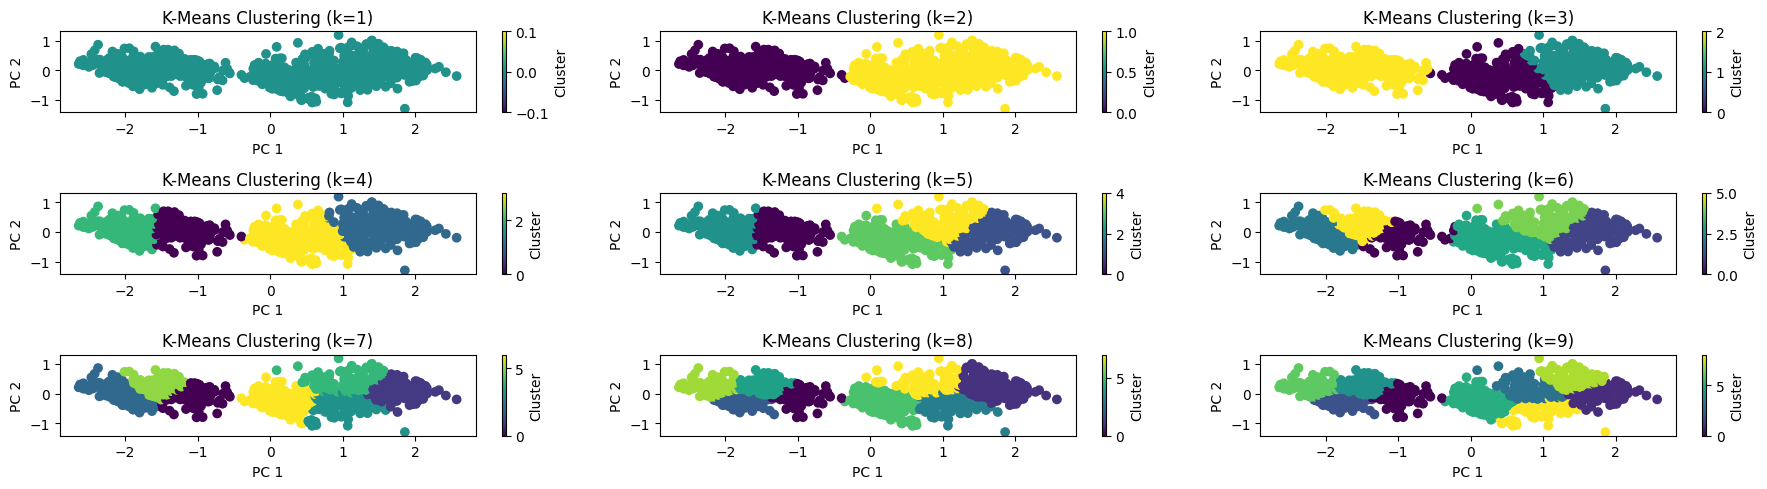

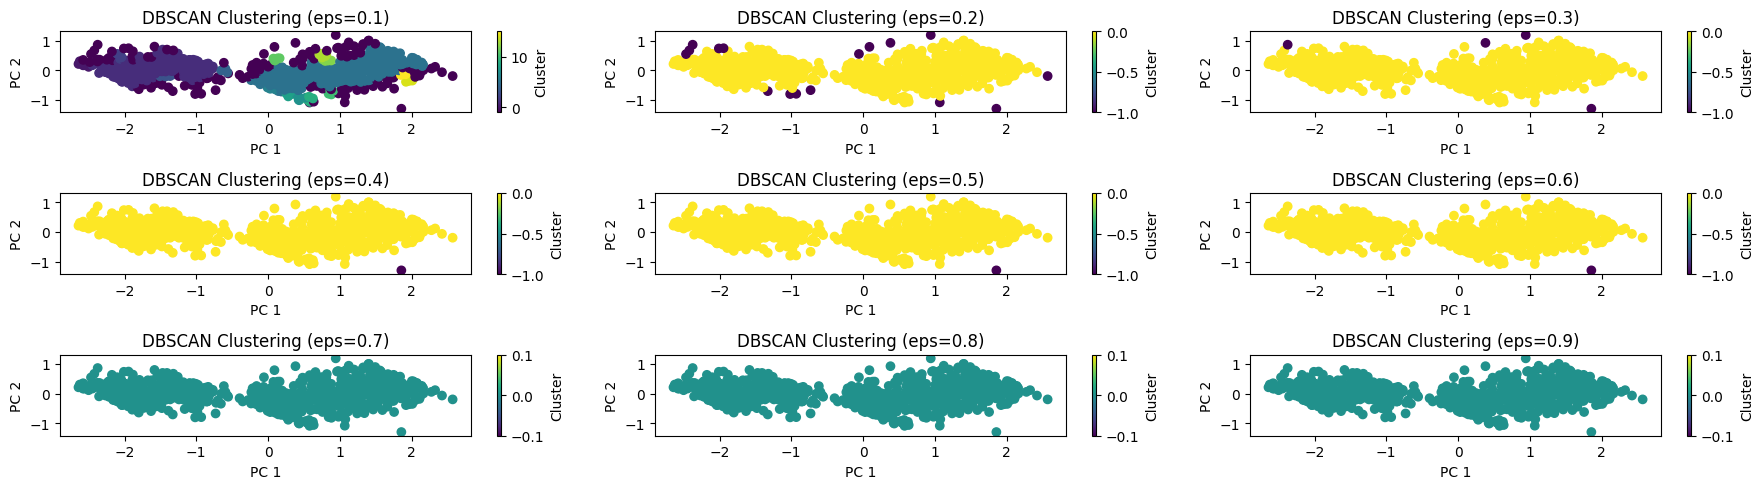

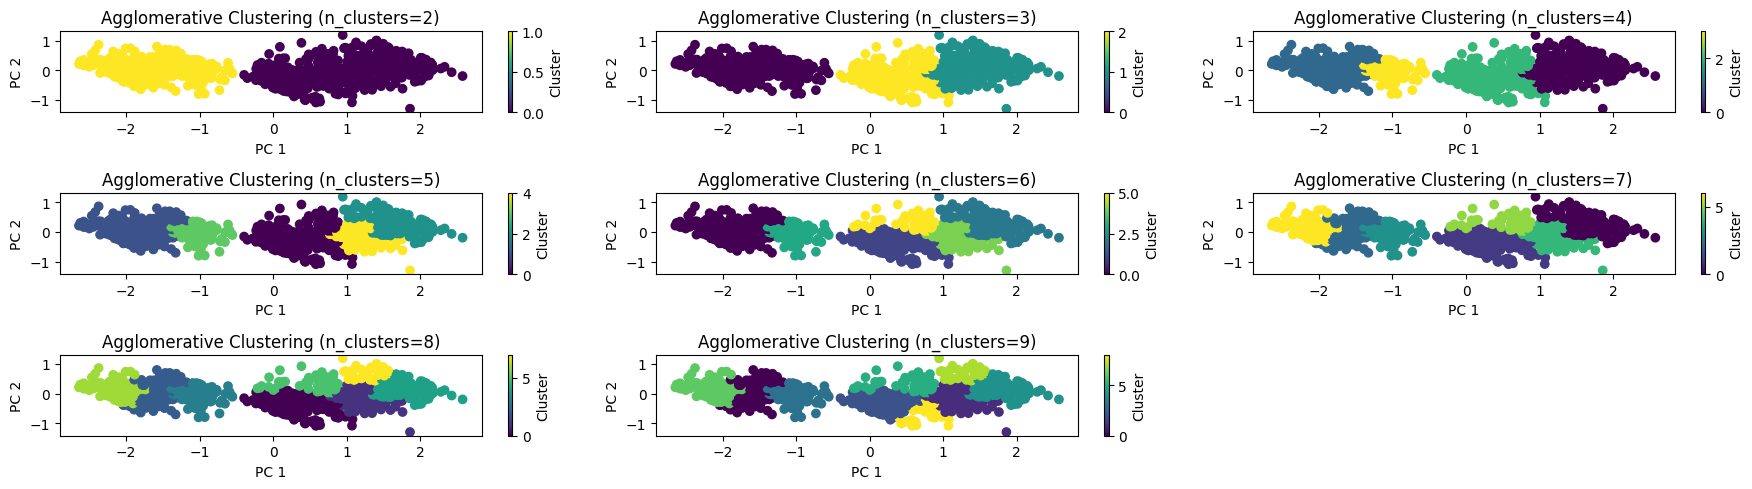

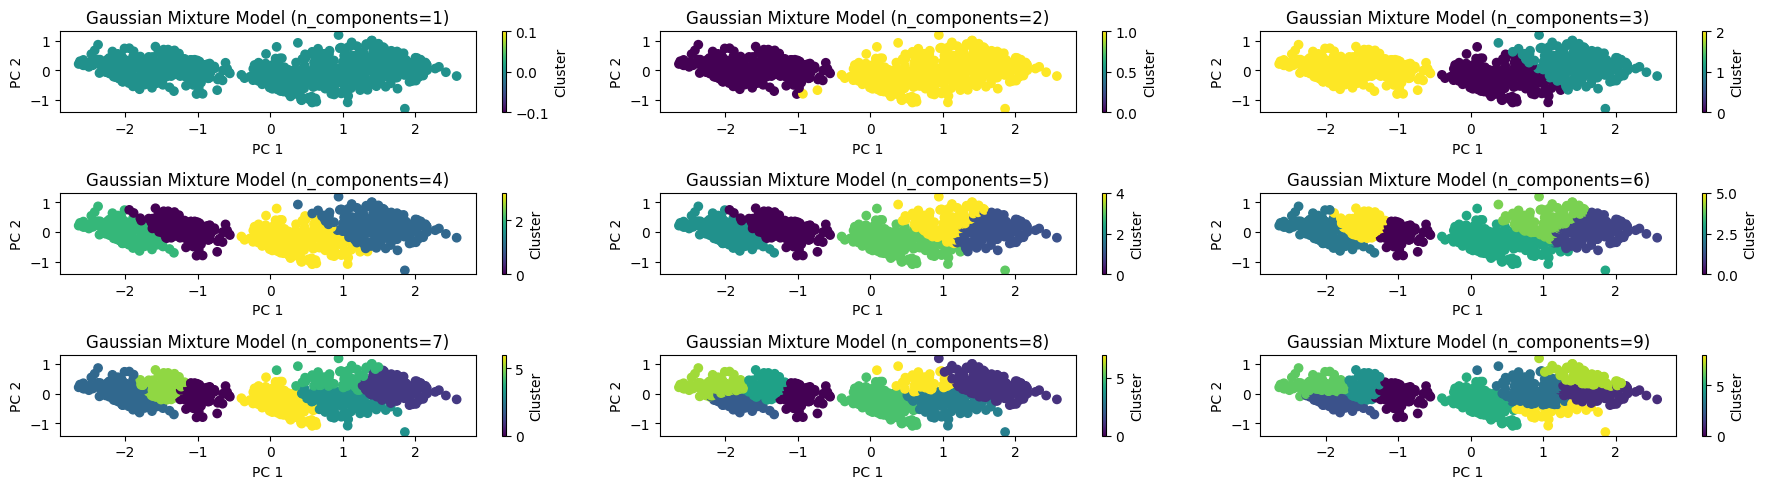

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


# Define features
X1 = data[['Gate Voltage','Gate Time', 'Noisy Drain Current']]  # Using Gate Time and Drain Current for clustering

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X1)

# Visualize results for optimal model after PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

model_names_un = ['K-Means', 'DBSCAN', 'Hierarchical', 'Gaussian Mixture']

# Plotting the results
plt.figure(figsize=(18, 5))
for i in range(1,10):
    kmeans_optimal = KMeans(n_clusters=i, random_state=42)
    kmeans_labels_optimal = kmeans_optimal.fit_predict(X_pca)
    plt.subplot(3, 3, i)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels_optimal, cmap='viridis')
    plt.xlabel('PC 1')
    plt.ylabel('PC 2')
    plt.title(f'K-Means Clustering (k={i})')
    plt.colorbar(label='Cluster')
plt.tight_layout()
plt.show()

# Plotting the results for DBSCAN
plt.figure(figsize=(18, 5))
for eps in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    dbscan_optimal = DBSCAN(eps=eps, min_samples=5)
    dbscan_labels_optimal = dbscan_optimal.fit_predict(X_pca)
    plt.subplot(3, 3, int(eps*10))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels_optimal, cmap='viridis')
    plt.xlabel('PC 1')
    plt.ylabel('PC 2')
    plt.title(f'DBSCAN Clustering (eps={eps})')
    plt.colorbar(label='Cluster')
plt.tight_layout()
plt.show()

# Plotting the results for Agglomerative Clustering
plt.figure(figsize=(18, 5))
for i in range(2,10):
    agglo_optimal = AgglomerativeClustering(n_clusters=i)
    agglo_labels_optimal = agglo_optimal.fit_predict(X_pca)
    plt.subplot(3, 3, i-1)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agglo_labels_optimal, cmap='viridis')
    plt.xlabel('PC 1')
    plt.ylabel('PC 2')
    plt.title(f'Agglomerative Clustering (n_clusters={i})')
    plt.colorbar(label='Cluster')
plt.tight_layout()
plt.show()

# Plotting the results for Gaussian Mixture Model
plt.figure(figsize=(18, 5))
for i in range(1,10):
    gmm_optimal = GaussianMixture(n_components=i, random_state=42)
    gmm_labels_optimal = gmm_optimal.fit_predict(X_pca)
    plt.subplot(3, 3, i)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=gmm_labels_optimal, cmap='viridis')
    plt.xlabel('PC 1')
    plt.ylabel('PC 2')
    plt.title(f'Gaussian Mixture Model (n_components={i})')
    plt.colorbar(label='Cluster')
plt.tight_layout()
plt.show()

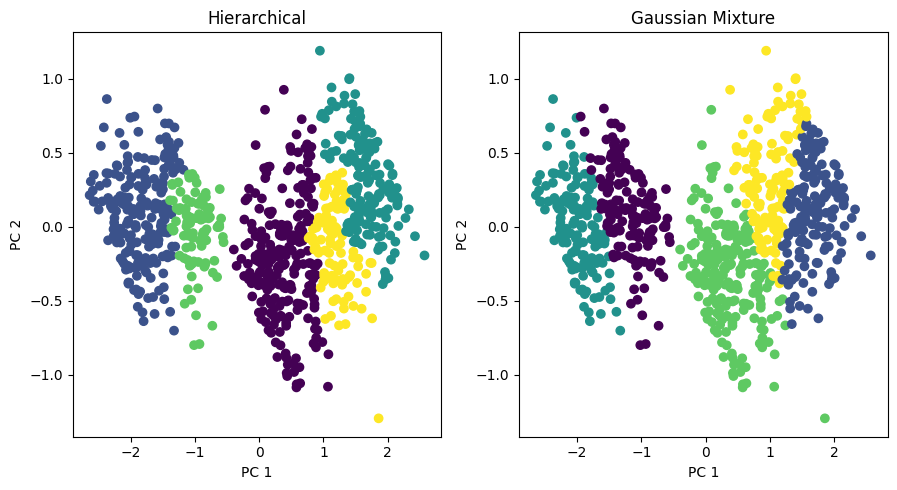

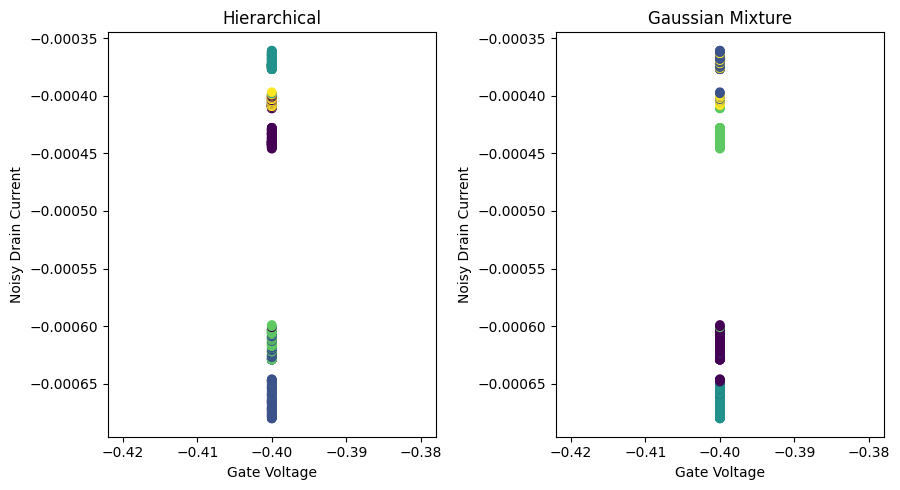

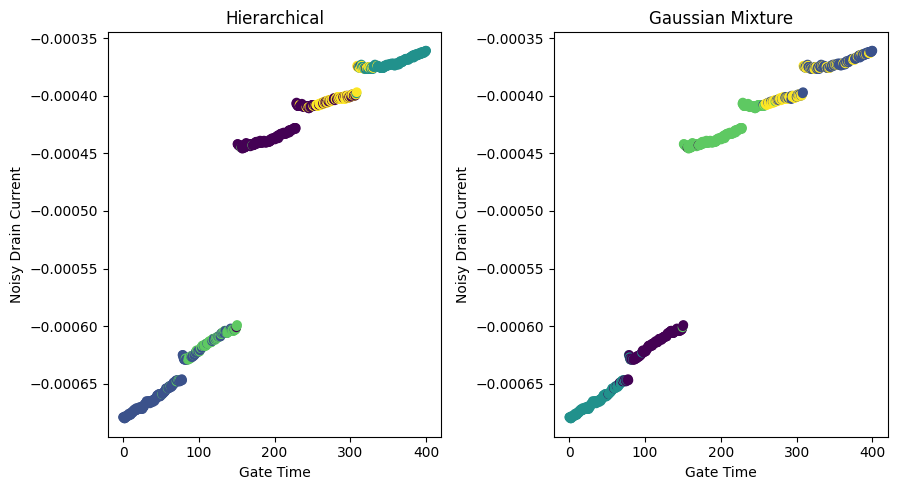

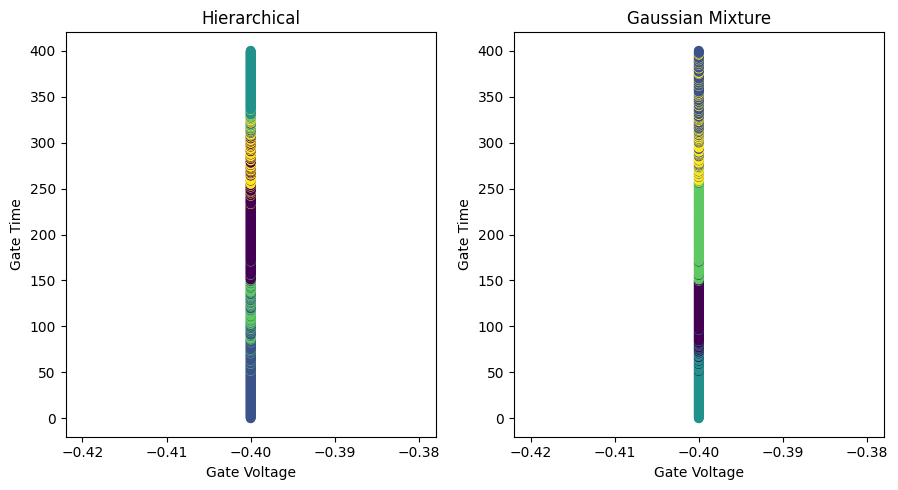

In [ ]:
#Optimal Models
model_names_un = ['Hierarchical','Gaussian Mixture']#['K-Means', 'DBSCAN', 'Hierarchical', 'Gaussian Mixture']
predictions_un = []

# K-Means Clustering
#kmeans = KMeans(n_clusters=5, random_state=42)
#kmeans_labels = kmeans.fit_predict(X_pca)
#predictions_un.append(kmeans_labels)

# DBSCAN Clustering
#dbscan = DBSCAN(eps=0.1, min_samples=5)
#dbscan_labels = dbscan.fit_predict(X_pca)
#predictions_un.append(dbscan_labels)

# Hierarchical Clustering
agglo = AgglomerativeClustering(n_clusters=5)
agglo_labels = agglo.fit_predict(X_pca)
predictions_un.append(agglo_labels)

# Gaussian Mixture Model
gmm = GaussianMixture(n_components=5, random_state=42) # Adjust n_components as needed
gmm_labels = gmm.fit_predict(X_pca)
predictions_un.append(gmm_labels)

# Apply PCA for visualization
# pca = PCA(n_components=2)
# X_pca = pca.fit_transform(X_scaled)

# Plotting the results
plt.figure(figsize=(18, 5))
for i, name in enumerate(model_names_un):
    plt.subplot(1, 4, i + 1)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=predictions_un[i], cmap='viridis', label=name)
    plt.title(name)
    plt.xlabel('PC 1')
    plt.ylabel('PC 2')
plt.tight_layout()
plt.show()

# Plotting the results
plt.figure(figsize=(18, 5))
for i, name in enumerate(model_names_un):
    plt.subplot(1, 4, i + 1)
    plt.scatter(data['Gate Voltage'], data['Drain Current'], c=predictions_un[i], cmap='viridis', label=name)
    plt.title(name)
    plt.xlabel('Gate Voltage')
    plt.ylabel('Noisy Drain Current')
plt.tight_layout()
plt.show()

# Plotting the results
plt.figure(figsize=(18, 5))
for i, name in enumerate(model_names_un):
    plt.subplot(1, 4, i + 1)
    plt.scatter(data['Gate Time'], data['Drain Current'], c=predictions_un[i], cmap='viridis', label=name)
    plt.title(name)
    plt.xlabel('Gate Time')
    plt.ylabel('Noisy Drain Current')
plt.tight_layout()
plt.show()

# Plotting the results
plt.figure(figsize=(18, 5))
for i, name in enumerate(model_names_un):
    plt.subplot(1, 4, i + 1)
    plt.scatter(data['Gate Voltage'], data['Gate Time'], c=predictions_un[i], cmap='viridis', label=name)
    plt.title(name)
    plt.xlabel('Gate Voltage')
    plt.ylabel('Gate Time')
plt.tight_layout()
plt.show()

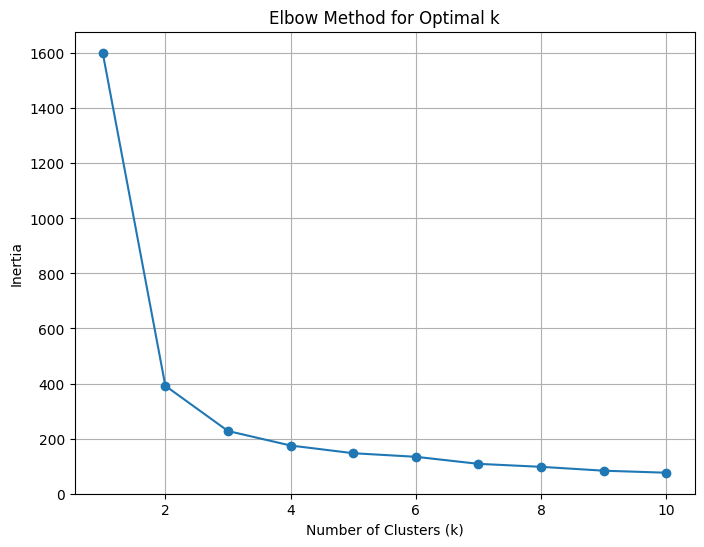

In [ ]:
# Tuning KMeans parameters (example)
inertia_values = []
for k in range(1, 11):  # Test k values from 1 to 10
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pca)
    inertia_values.append(kmeans.inertia_)

# Plotting the elbow method
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), inertia_values, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()

# With Gate Time and Drain Current - on Noise data

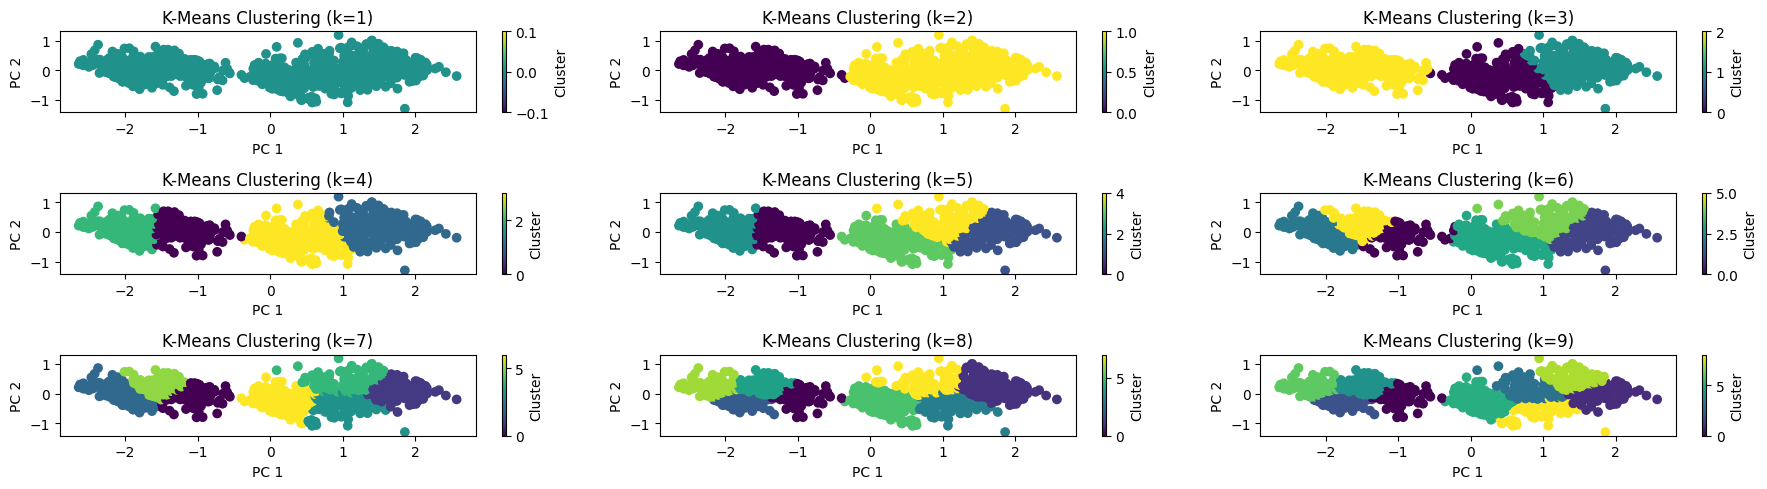

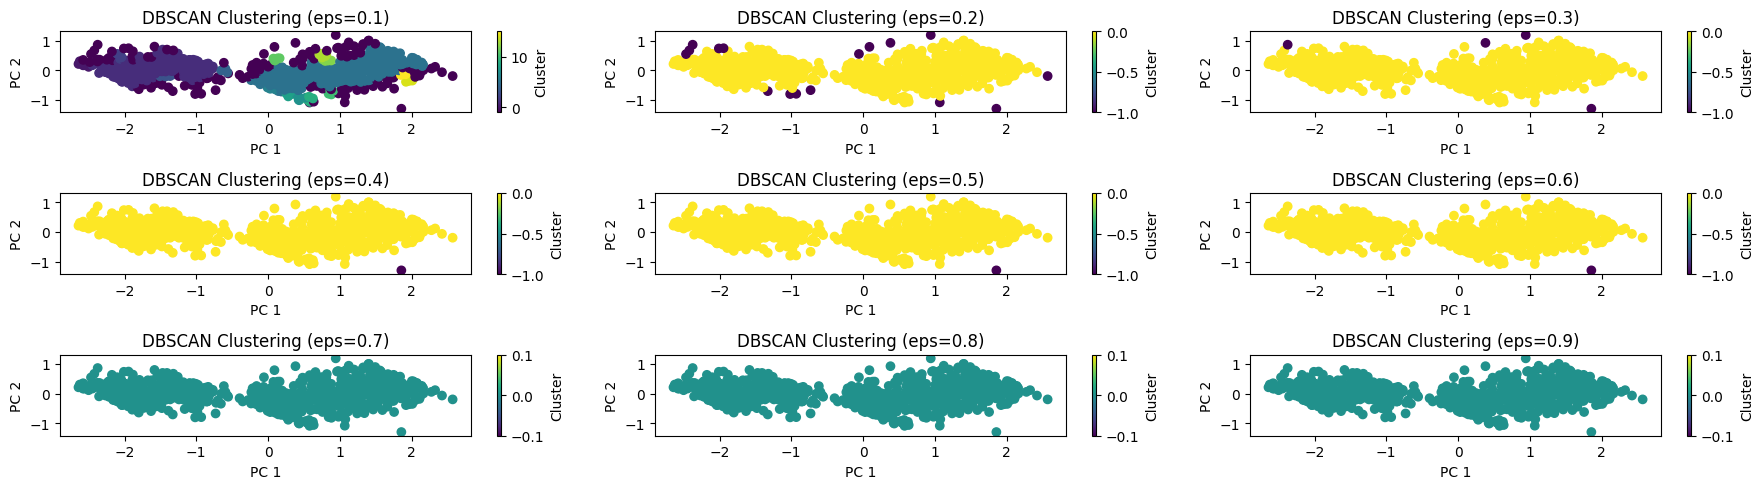

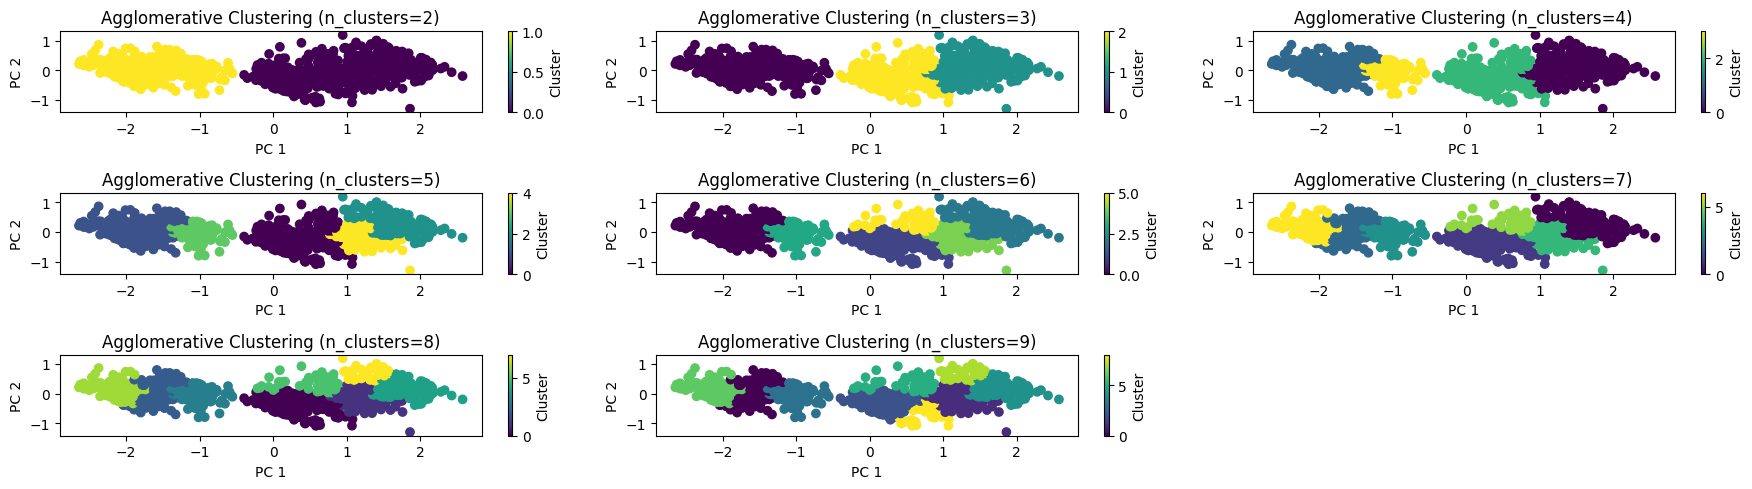

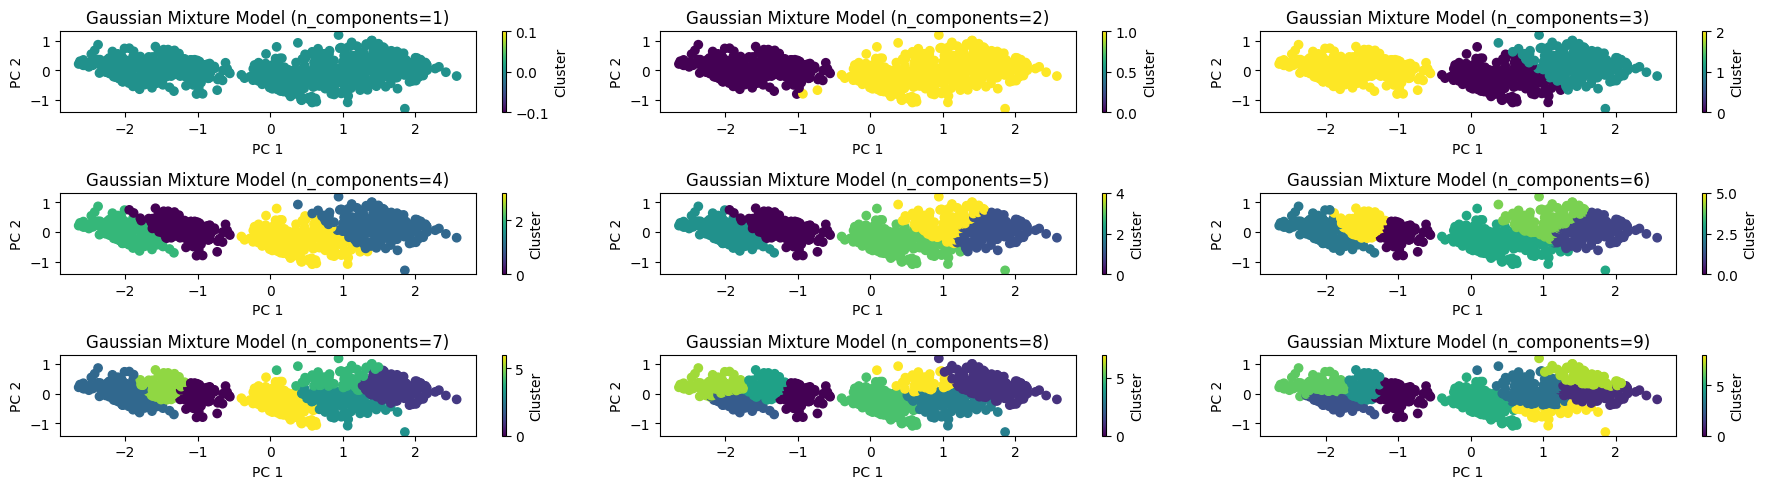

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


# Define features
X2 = data[['Gate Time', 'Noisy Drain Current']]  # Using Gate Time and Drain Current for clustering

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X2)

# Visualize results for optimal model after PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

model_names_un = ['K-Means', 'DBSCAN', 'Hierarchical', 'Gaussian Mixture']

# Plotting the results
plt.figure(figsize=(18, 5))
for i in range(1,10):
    kmeans_optimal = KMeans(n_clusters=i, random_state=42)
    kmeans_labels_optimal = kmeans_optimal.fit_predict(X_pca)
    plt.subplot(3, 3, i)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels_optimal, cmap='viridis')
    plt.xlabel('PC 1')
    plt.ylabel('PC 2')
    plt.title(f'K-Means Clustering (k={i})')
    plt.colorbar(label='Cluster')
plt.tight_layout()
plt.show()

# Plotting the results for DBSCAN
plt.figure(figsize=(18, 5))
for eps in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    dbscan_optimal = DBSCAN(eps=eps, min_samples=5)
    dbscan_labels_optimal = dbscan_optimal.fit_predict(X_pca)
    plt.subplot(3, 3, int(eps*10))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels_optimal, cmap='viridis')
    plt.xlabel('PC 1')
    plt.ylabel('PC 2')
    plt.title(f'DBSCAN Clustering (eps={eps})')
    plt.colorbar(label='Cluster')
plt.tight_layout()
plt.show()

# Plotting the results for Agglomerative Clustering
plt.figure(figsize=(18, 5))
for i in range(2,10):
    agglo_optimal = AgglomerativeClustering(n_clusters=i)
    agglo_labels_optimal = agglo_optimal.fit_predict(X_pca)
    plt.subplot(3, 3, i-1)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agglo_labels_optimal, cmap='viridis')
    plt.xlabel('PC 1')
    plt.ylabel('PC 2')
    plt.title(f'Agglomerative Clustering (n_clusters={i})')
    plt.colorbar(label='Cluster')
plt.tight_layout()
plt.show()

# Plotting the results for Gaussian Mixture Model
plt.figure(figsize=(18, 5))
for i in range(1,10):
    gmm_optimal = GaussianMixture(n_components=i, random_state=42)
    gmm_labels_optimal = gmm_optimal.fit_predict(X_pca)
    plt.subplot(3, 3, i)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=gmm_labels_optimal, cmap='viridis')
    plt.xlabel('PC 1')
    plt.ylabel('PC 2')
    plt.title(f'Gaussian Mixture Model (n_components={i})')
    plt.colorbar(label='Cluster')
plt.tight_layout()
plt.show()

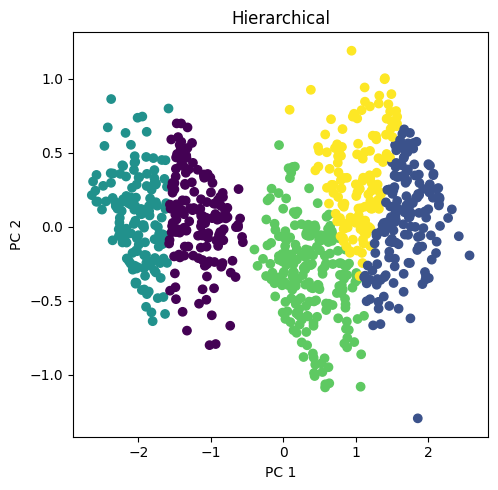

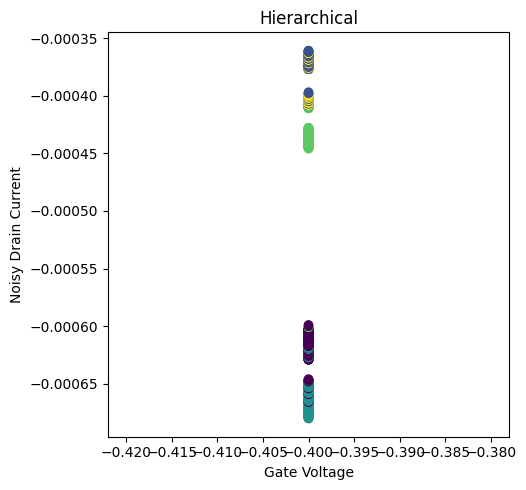

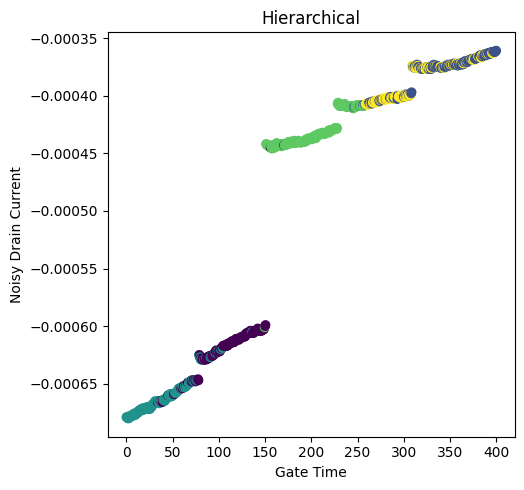

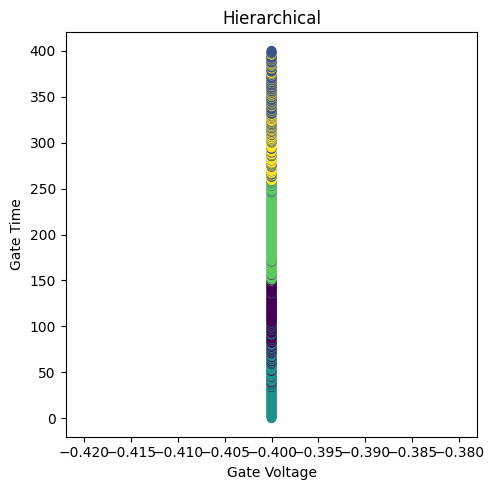

In [ ]:
#Optimal Models
# model_names_un = ['K-Means', 'DBSCAN', 'Hierarchical', 'Gaussian Mixture']
model_names_un = ['K-Means','Hierarchical', 'Gaussian Mixture']
predictions_un = []

# K-Means Clustering
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans_labels = kmeans.fit_predict(X_pca)
predictions_un.append(kmeans_labels)

# DBSCAN Clustering
#dbscan = DBSCAN(eps=0.1, min_samples=5)
#dbscan_labels = dbscan.fit_predict(X_pca)
#predictions_un.append(dbscan_labels)

# Hierarchical Clustering
agglo = AgglomerativeClustering(n_clusters=5)
agglo_labels = agglo.fit_predict(X_pca)
predictions_un.append(agglo_labels)

# Gaussian Mixture Model
gmm = GaussianMixture(n_components=5, random_state=42) # Adjust n_components as needed
gmm_labels = gmm.fit_predict(X_pca)
predictions_un.append(gmm_labels)

# Apply PCA for visualization
# pca = PCA(n_components=2)
# X_pca = pca.fit_transform(X_scaled)

# Plotting the results
plt.figure(figsize=(18, 5))
for i, name in enumerate(model_names_un[1:2]):
    plt.subplot(1, 4, i + 1)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=predictions_un[i], cmap='viridis', label=name)
    plt.title(name)
    plt.xlabel('PC 1')
    plt.ylabel('PC 2')
plt.tight_layout()
plt.show()

# Plotting the results
plt.figure(figsize=(18, 5))
for i, name in enumerate(model_names_un[1:2]):
    plt.subplot(1, 4, i + 1)
    plt.scatter(data['Gate Voltage'], data['Drain Current'], c=predictions_un[i], cmap='viridis', label=name)
    plt.title(name)
    plt.xlabel('Gate Voltage')
    plt.ylabel('Noisy Drain Current')
plt.tight_layout()
plt.show()

# Plotting the results
plt.figure(figsize=(18, 5))
for i, name in enumerate(model_names_un[1:2]):
    plt.subplot(1, 4, i + 1)
    plt.scatter(data['Gate Time'], data['Drain Current'], c=predictions_un[i], cmap='viridis', label=name)
    plt.title(name)
    plt.xlabel('Gate Time')
    plt.ylabel('Noisy Drain Current')
plt.tight_layout()
plt.show()

# Plotting the results
plt.figure(figsize=(18, 5))
for i, name in enumerate(model_names_un[1:2]):
    plt.subplot(1, 4, i + 1)
    plt.scatter(data['Gate Voltage'], data['Gate Time'], c=predictions_un[i], cmap='viridis', label=name)
    plt.title(name)
    plt.xlabel('Gate Voltage')
    plt.ylabel('Gate Time')
plt.tight_layout()
plt.show()